In [4]:
import os
import ROOT
import pandas as pd
import numpy as np

# =====================================================
# WORKING DIRECTORY AND SETTINGS
# =====================================================
working_directory = "/root/geant4/detector/Lung_ICRP"
os.chdir(working_directory)

file_path = "lung1_tissueTumor.root"
tree_name = "t"

selected_volumes = [2, 3, 4, 5]
selected_pdg = 22

excel_file = "lung1_tissueTumor_all_gamma_data.xlsx"

print("Working directory:", os.getcwd())
print("Input file:", os.path.abspath(file_path))

# =====================================================
# OPEN ROOT FILE
# =====================================================
root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise OSError(f"Could not open {os.path.abspath(file_path)}")

tree = root_file.Get(tree_name)

if not tree:
    root_file.Close()
    raise KeyError(f"TTree '{tree_name}' not found")

print("Total TTree entries:", tree.GetEntries())

# =====================================================
# SAFE VECTOR READER
# =====================================================
def safe_value(vector, index, default=np.nan):
    """
    Return vector[index] when available.
    Otherwise return NaN.
    """
    if index < len(vector):
        return vector[index]
    return default

# =====================================================
# STORAGE
# =====================================================
selected_volumes = [2, 3, 4, 5]

volume_data = {
    volume: [] for volume in selected_volumes
}

combined_data = []

column_order = [
    "tree_entry",
    "vector_index",
    "vlm",
    "pdg",
    "pro",
    "stp",
    "k",
    "et",
    "de",
    "x",
    "y",
    "z",
    "px",
    "py",
    "pz"
]

# =====================================================
# LOOP THROUGH ROOT DATA
# =====================================================
for tree_entry, event in enumerate(tree):

    # Use pdg as the principal record length
    number_of_records = len(event.pdg)

    for vector_index in range(number_of_records):

        pdg_value = int(event.pdg[vector_index])

        # vlm must exist for this record
        if vector_index >= len(event.vlm):
            continue

        volume_value = int(event.vlm[vector_index])

        # Keep only gammas
        if pdg_value != selected_pdg:
            continue

        # Keep only volumes 2, 3, 4, 5
        if volume_value not in selected_volumes:
            continue

        row = {
            "tree_entry": tree_entry,
            "vector_index": vector_index,

            "vlm": volume_value,
            "pdg": pdg_value,

            "pro": int(safe_value(event.pro, vector_index, -1)),
            "stp": int(safe_value(event.stp, vector_index, -1)),

            "k": float(safe_value(event.k, vector_index)),
            "et": float(safe_value(event.et, vector_index)),
            "de": float(safe_value(event.de, vector_index)),

            "x": float(safe_value(event.x, vector_index)),
            "y": float(safe_value(event.y, vector_index)),
            "z": float(safe_value(event.z, vector_index)),

            "px": float(safe_value(event.px, vector_index)),
            "py": float(safe_value(event.py, vector_index)),
            "pz": float(safe_value(event.pz, vector_index))
        }

        volume_data[volume_value].append(row)
        combined_data.append(row)

# =====================================================
# CREATE DATAFRAMES
# =====================================================
dataframes = {
    volume: pd.DataFrame(
        volume_data[volume],
        columns=column_order
    )
    for volume in selected_volumes
}

df_all = pd.DataFrame(
    combined_data,
    columns=column_order
)

# =====================================================
# WRITE EXCEL WORKBOOK
# =====================================================
with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

    for volume in selected_volumes:
        dataframes[volume].to_excel(
            writer,
            sheet_name=f"Volume_{volume}",
            index=False
        )

    df_all.to_excel(
        writer,
        sheet_name="All_Volumes",
        index=False
    )

print("Excel file saved at:")
print(os.path.abspath(excel_file))
print("File exists:", os.path.exists(excel_file))
# =====================================================
# CONFIRM OUTPUT
# =====================================================
print("\nRecords saved:")

for volume in selected_volumes:
    print(f"Volume {volume}: {len(dataframes[volume])}")

print("All volumes:", len(df_all))

print("\nExcel file saved at:")
print(os.path.abspath(excel_file))

print("\nFile exists:", os.path.exists(excel_file))
print("File size:", os.path.getsize(excel_file), "bytes")

display(df_all.head(10))

Working directory: /root/geant4/detector/Lung_ICRP
Input file: /root/geant4/detector/Lung_ICRP/lung1_tissueTumor.root
Total TTree entries: 50000
Excel file saved at:
/root/geant4/detector/Lung_ICRP/lung1_tissueTumor_all_gamma_data.xlsx
File exists: True

Records saved:
Volume 2: 101267
Volume 3: 51685
Volume 4: 668
Volume 5: 478
All volumes: 154098

Excel file saved at:
/root/geant4/detector/Lung_ICRP/lung1_tissueTumor_all_gamma_data.xlsx

File exists: True
File size: 15951322 bytes


,tree_entry,vector_index,vlm,pdg,pro,stp,k,et,de,x,y,z,px,py,pz
0,0,2,2,22,1092,2,662.0,NaN,0.0,0.0,2.5,0.0,0.0,-1.0,0.0
1,0,3,3,22,1092,3,662.0,NaN,0.0,0.0,-2.5,0.0,0.0,-1.0,0.0
2,0,4,2,22,1092,4,662.0,NaN,0.0,0.0,-10.0,0.0,0.0,-1.0,0.0
3,1,2,2,22,1092,2,662.0,NaN,0.0,0.0,2.5,0.0,0.0,-1.0,0.0
4,1,3,3,22,1092,3,662.0,NaN,0.0,0.0,-2.5,0.0,0.0,-1.0,0.0
5,1,4,2,22,1092,4,662.0,NaN,0.0,0.0,-10.0,0.0,0.0,-1.0,0.0
6,2,2,2,22,1092,2,662.0,NaN,0.0,0.0,2.5,0.0,0.0,-1.0,0.0
7,2,3,3,22,1092,3,662.0,NaN,0.0,0.0,-2.5,0.0,0.0,-1.0,0.0
8,2,4,2,22,1092,4,662.0,NaN,0.0,0.0,-10.0,0.0,0.0,-1.0,0.0
9,3,2,2,22,1092,2,662.0,NaN,0.0,0.0,2.5,0.0,0.0,-1.0,0.0


Working directory:
/root/geant4/detector/Lung_ICRP

Input ROOT file:
/root/geant4/detector/Lung_ICRP/lung1_tissueTumor.root

Total TTree entries:
50000

Available branches:
['de', 'dl', 'dt', 'et', 'k', 'l', 'm', 'n', 'p', 'pdg', 'pid', 'pro', 'px', 'py', 'pz', 'q', 'stp', 't', 'trk', 'vlm', 'x', 'xx', 'y', 'yy', 'z', 'zz']

et branch available: True

Original gamma workbook saved:
/root/geant4/detector/Lung_ICRP/lung1_tissueTumor_all_gamma_data.xlsx

Original records:
Volume 2: 101267
Volume 3: 51685
Volume 4: 668
Volume 5: 478
All volumes: 154098

Q-analysis records before cleaning:
4174

Usable Q records:
4174
Volume 2 Q records: 1870
Volume 3 Q records: 2304

Detailed Q workbook saved:
/root/geant4/detector/Lung_ICRP/lung1_volume2_volume3_Q_detailed.xlsx

Summary workbook saved:
/root/geant4/detector/Lung_ICRP/lung1_volume2_volume3_Q_theta_summary.xlsx

Records used in plots:
Volume 2: 1870
Volume 3: 2304


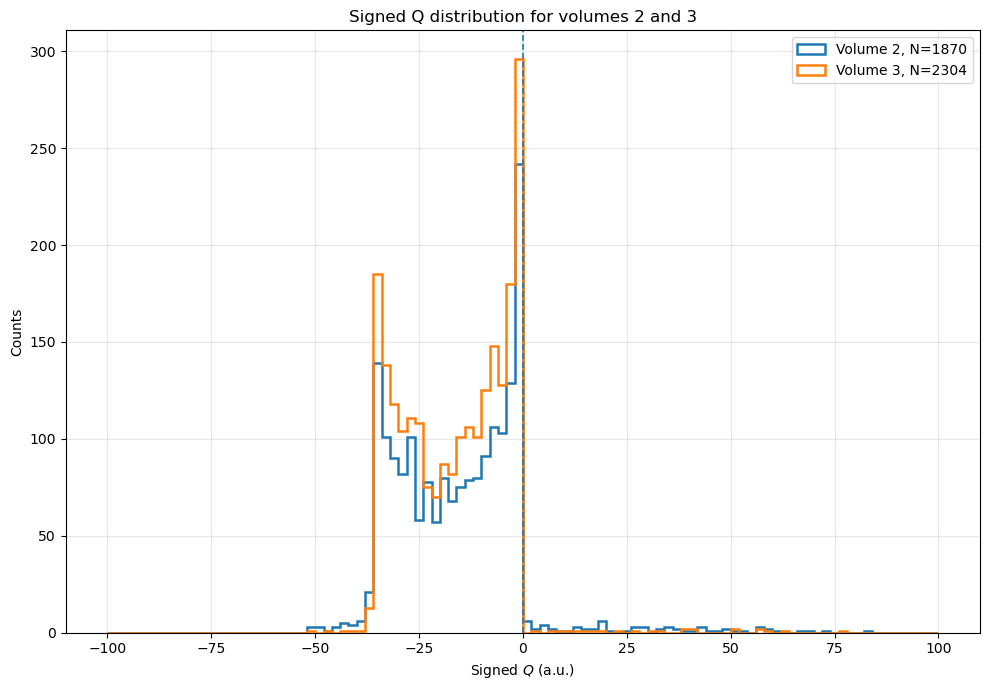

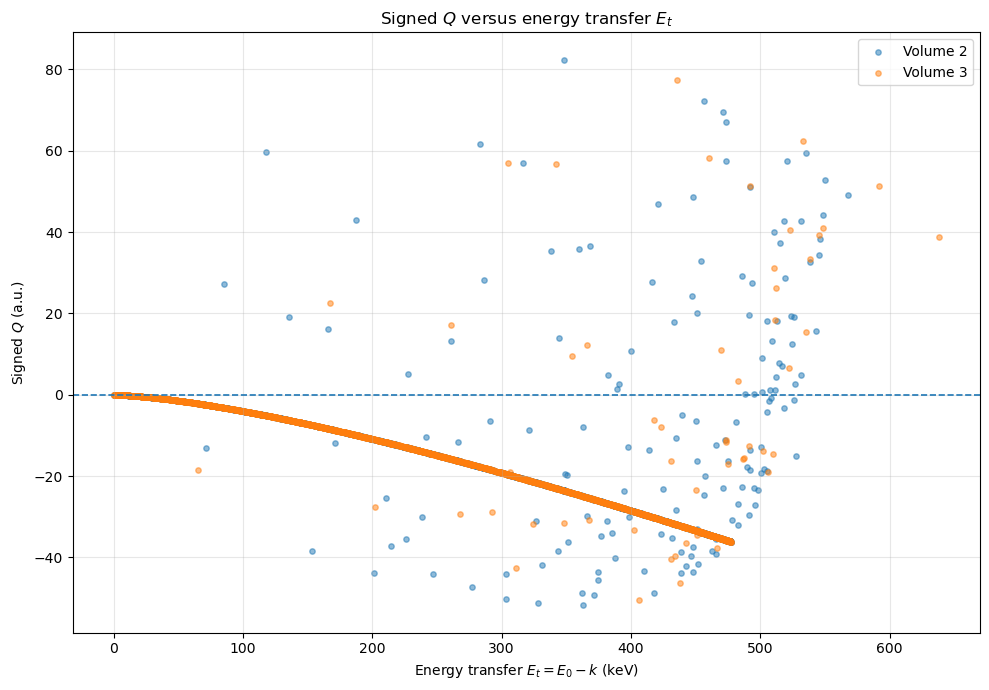

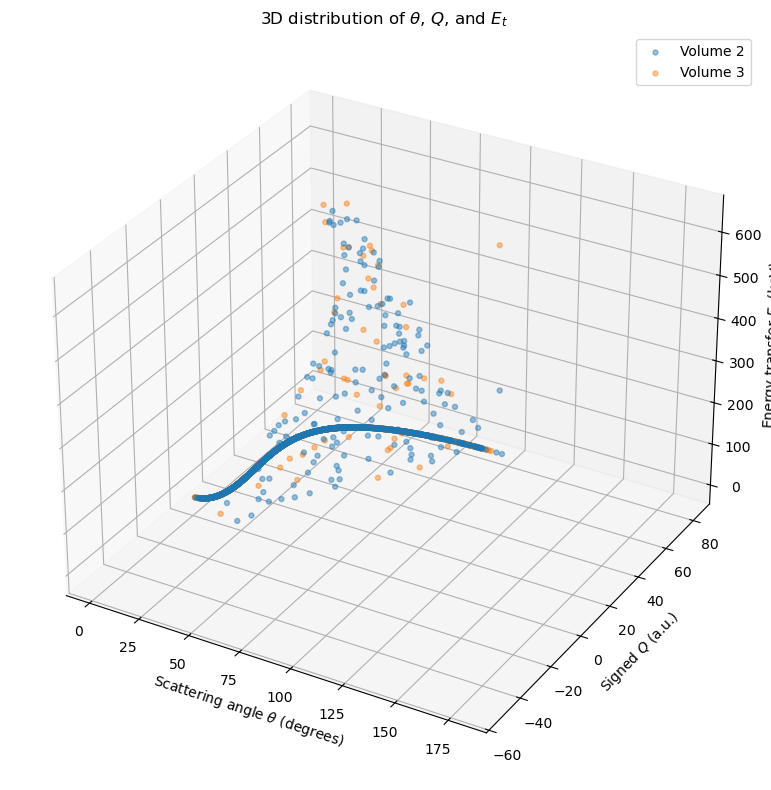

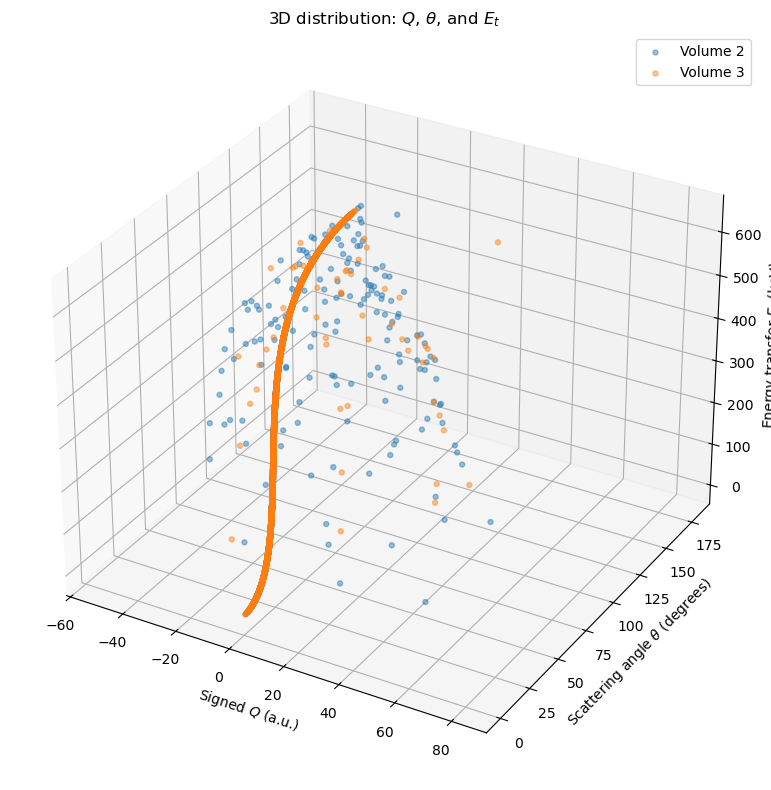


First detailed Q records:


,tree_entry,vector_index,vlm,pdg,pro,stp,k,E0_keV,Eprime_keV,Et_keV,...,Eprime_difference_keV,qc_keV_c,Q_keV_c,Q_au,Abs_Q_keV_c,Abs_Q_au,de,x,y,z
13,4,3,3,22,2013,3,189.930680,662.0,189.930680,472.069320,...,-1.060188e-05,839.823350,-132.676357,-35.595071,132.676357,35.595071,0.0,0.0,-1.637053,0.0
173,57,3,3,22,2013,3,348.702174,662.0,348.702174,313.297826,...,-1.291796e-05,646.796121,-75.878240,-20.356991,75.878240,20.356991,0.0,0.0,-0.610534,0.0
212,70,2,2,22,2013,2,656.264320,662.0,656.264320,5.735680,...,-4.450879e-07,76.777278,-0.214240,-0.057477,0.214240,0.057477,0.0,0.0,8.658919,0.0
230,75,3,3,22,2013,3,560.996324,662.0,560.996324,101.003676,...,-6.700068e-06,336.789666,-15.145557,-4.063325,15.145557,4.063325,0.0,0.0,-0.909895,0.0
235,76,3,3,22,2013,3,654.214698,662.0,654.214698,7.785302,...,-6.022512e-07,89.538668,-0.338459,-0.090803,0.338459,0.090803,0.0,0.0,0.447901,0.0
338,110,3,3,22,2013,3,621.541198,662.0,621.541198,40.458802,...,-2.973479e-06,207.329983,-3.947599,-1.059082,3.947599,1.059082,0.0,0.0,-1.831096,0.0
346,112,4,2,22,2013,4,295.137350,662.0,295.137350,366.862650,...,-1.280294e-05,713.807420,-94.274850,-25.292524,94.274850,25.292524,0.0,0.0,-7.730796,0.0
374,121,4,2,22,2013,4,473.338040,662.0,473.338040,188.661960,...,-1.055936e-05,477.917824,-37.237908,-9.990371,37.237908,9.990371,0.0,0.0,-8.894200,0.0
379,122,4,2,22,2013,4,574.777793,662.0,574.777793,87.222207,...,-5.928012e-06,311.044400,-12.229293,-3.280935,12.229293,3.280935,0.0,0.0,-5.917304,0.0
397,127,4,2,22,2013,4,496.961768,662.0,496.961768,165.038232,...,-9.698164e-06,442.613073,-30.769092,-8.254885,30.769092,8.254885,0.0,0.0,-2.983939,0.0



Volume 2 angular summary:


,volume,theta_bin_left_deg,theta_bin_right_deg,theta_bin_center_deg,counts,mean_theta_deg,std_theta_deg,mean_Eprime_keV,std_Eprime_keV,mean_Et_keV,std_Et_keV,mean_qc_keV_c,std_qc_keV_c,mean_Q_keV_c,std_Q_keV_c,mean_Q_au,std_Q_au,mean_Abs_Q_au,std_Abs_Q_au
0,2,0.0,2.0,1.0,1,1.498323,NaN,661.706901,NaN,0.293099,NaN,17.309894,NaN,-0.002481,NaN,-0.000666,NaN,0.000666,NaN
1,2,2.0,4.0,3.0,3,3.057938,0.393089,660.767788,0.305147,1.232212,0.305147,35.315459,4.535989,-0.021712,0.007750,-0.005825,0.002079,0.005825,0.002079
2,2,4.0,6.0,5.0,8,4.768870,0.428447,659.024010,0.554323,2.975990,0.554323,55.039003,4.932495,-0.081055,0.023587,-0.021746,0.006328,0.021746,0.006328
3,2,6.0,8.0,7.0,19,6.864125,0.623486,655.864307,1.100474,6.135693,1.100474,79.126276,7.154407,-0.239661,0.064133,-0.064297,0.017206,0.064297,0.017206
4,2,8.0,10.0,9.0,23,9.047477,0.551870,651.464961,1.255188,10.535039,1.255188,104.121568,6.301303,-0.534729,0.094681,-0.143460,0.025402,0.143460,0.025402
5,2,10.0,12.0,11.0,25,11.143191,0.501184,646.190275,1.368416,15.809725,1.368416,127.977283,5.688512,-0.978225,0.124896,-0.262443,0.033508,0.262443,0.033508
6,2,12.0,14.0,13.0,30,13.028750,0.607566,615.290331,97.698816,46.709669,97.698816,166.654021,68.896636,17.803339,73.731789,4.776368,19.781130,5.541353,19.573657
7,2,14.0,16.0,15.0,32,15.075313,0.620514,630.826346,15.892565,31.173654,15.892565,173.093009,7.327745,4.683460,39.722347,1.256502,10.656908,2.471994,10.435111
8,2,16.0,18.0,17.0,26,16.898475,0.609954,608.221648,85.760966,53.778352,85.760966,204.258124,57.024041,10.939300,54.665474,2.934850,14.665925,4.518886,14.241140
9,2,18.0,20.0,19.0,38,19.053734,0.559451,606.903458,69.698318,55.096542,69.698318,223.159777,44.642742,2.262376,41.337601,0.606961,11.090257,2.928328,10.703517



Volume 3 angular summary:


,volume,theta_bin_left_deg,theta_bin_right_deg,theta_bin_center_deg,counts,mean_theta_deg,std_theta_deg,mean_Eprime_keV,std_Eprime_keV,mean_Et_keV,std_Et_keV,mean_qc_keV_c,std_qc_keV_c,mean_Q_keV_c,std_Q_keV_c,mean_Q_au,std_Q_au,mean_Abs_Q_au,std_Abs_Q_au
0,3,0.0,2.0,1.0,3,1.575181,0.303685,661.668071,0.117903,0.331929,0.117903,18.197472,3.507679,-0.003088,0.001502,-0.000829,0.000403,0.000829,0.000403
1,3,2.0,4.0,3.0,7,3.663155,0.372373,660.237164,0.340505,1.762836,0.340505,42.296700,4.294796,-0.037023,0.010193,-0.009933,0.002735,0.009933,0.002735
2,3,4.0,6.0,5.0,11,5.011046,0.560650,658.702129,0.727494,3.297871,0.727494,57.826490,6.454320,-0.095057,0.031058,-0.025502,0.008332,0.025502,0.008332
3,3,6.0,8.0,7.0,33,7.024985,0.646345,642.601834,74.685388,19.398166,74.685388,91.628953,62.671731,8.491428,50.246618,2.278122,13.480412,2.410998,13.456559
4,3,8.0,10.0,9.0,18,8.918673,0.516957,651.761135,1.164837,10.238865,1.164837,102.651312,5.904107,-0.512153,0.086942,-0.137403,0.023325,0.137403,0.023325
5,3,10.0,12.0,11.0,24,10.953083,0.554217,646.704319,1.504640,15.295681,1.504640,125.818687,6.291889,-0.931824,0.136458,-0.249994,0.036610,0.249994,0.036610
6,3,12.0,14.0,13.0,35,13.166436,0.588318,640.162974,1.858244,21.837026,1.858244,150.847318,6.629093,-1.583245,0.198279,-0.424761,0.053195,0.424761,0.053195
7,3,14.0,16.0,15.0,27,14.956707,0.595408,634.133633,2.117560,27.866367,2.117560,170.931611,6.651462,-2.274456,0.257524,-0.610202,0.069090,0.610202,0.069090
8,3,16.0,18.0,17.0,31,16.950601,0.569963,626.699569,2.232294,35.300431,2.232294,193.104733,6.304841,-3.229446,0.303093,-0.866412,0.081315,0.866412,0.081315
9,3,18.0,20.0,19.0,42,19.063516,0.576102,606.376733,75.516763,55.623267,75.516763,224.176837,50.550983,1.167047,36.539855,0.313101,9.803094,2.654929,9.432948



FILES CREATED

 /root/geant4/detector/Lung_ICRP/lung1_tissueTumor_all_gamma_data.xlsx
Exists: True
Size: 15951354 bytes

 /root/geant4/detector/Lung_ICRP/lung1_volume2_volume3_Q_detailed.xlsx
Exists: True
Size: 2062920 bytes

 /root/geant4/detector/Lung_ICRP/lung1_volume2_volume3_Q_theta_summary.xlsx
Exists: True
Size: 72944 bytes

 /root/geant4/detector/Lung_ICRP/volume2_Q_theta_summary.csv
Exists: True
Size: 24946 bytes

 /root/geant4/detector/Lung_ICRP/volume3_Q_theta_summary.csv
Exists: True
Size: 25252 bytes

 /root/geant4/detector/Lung_ICRP/volume2_volume3_Q_theta_summary.csv
Exists: True
Size: 49943 bytes

 /root/geant4/detector/Lung_ICRP/volume2_Q_detailed.csv
Exists: True
Size: 733318 bytes

 /root/geant4/detector/Lung_ICRP/volume3_Q_detailed.csv
Exists: True
Size: 901749 bytes


In [5]:
import os
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Required once if openpyxl is missing:
# import sys
# !{sys.executable} -m pip install openpyxl

# =====================================================
# 1. WORKING DIRECTORY AND INPUT SETTINGS
# =====================================================
working_directory = "/root/geant4/detector/Lung_ICRP"
os.chdir(working_directory)

file_path = "lung1_tissueTumor.root"
tree_name = "t"

# All gamma records exported from these volumes
selected_volumes = [2, 3, 4, 5]
selected_pdg = 22

# Physics settings
E0 = 662.0                 # incident gamma energy, keV
ME_C2 = 510.99895          # electron rest energy, keV
P_AU = 3.72738             # 1 atomic unit momentum, keV/c

# Incident beam direction from your macro:
# /gps/direction 0 -1 0
incident_direction = np.array([0.0, -1.0, 0.0])

# Geant4 process code used for Compton scattering
compton_process = 2013

# Set True to use only pro == 2013 for the Q analysis.
# Set False to use all gamma records in volumes 2 and 3.
use_compton_only = True

# Summary-bin settings
theta_bin_width = 2.0      # degrees

# Q histogram settings
q_min_au = -100.0
q_max_au = 100.0
q_bin_width_au = 2.0

# Optional limits for plotted data.
# Records outside this Q range remain in Excel but are
# omitted from plots when use_plot_q_limit=True.
use_plot_q_limit = True
plot_q_limit_au = 100.0

# =====================================================
# 2. OUTPUT FILE NAMES
# =====================================================
original_excel = "lung1_tissueTumor_all_gamma_data.xlsx"

q_detailed_excel = (
    "lung1_volume2_volume3_Q_detailed.xlsx"
)

q_summary_excel = (
    "lung1_volume2_volume3_Q_theta_summary.xlsx"
)

summary_csv_vlm2 = "volume2_Q_theta_summary.csv"
summary_csv_vlm3 = "volume3_Q_theta_summary.csv"
summary_csv_combined = (
    "volume2_volume3_Q_theta_summary.csv"
)

detailed_csv_vlm2 = "volume2_Q_detailed.csv"
detailed_csv_vlm3 = "volume3_Q_detailed.csv"

print("Working directory:")
print(os.getcwd())

print("\nInput ROOT file:")
print(os.path.abspath(file_path))

# =====================================================
# 3. CHECK AND OPEN ROOT FILE
# =====================================================
if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"ROOT file not found:\n{os.path.abspath(file_path)}"
    )

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise OSError(
        f"Could not open ROOT file:\n"
        f"{os.path.abspath(file_path)}"
    )

tree = root_file.Get(tree_name)

if not tree:
    root_file.Close()
    raise KeyError(
        f"TTree '{tree_name}' was not found."
    )

print("\nTotal TTree entries:")
print(tree.GetEntries())

# =====================================================
# 4. CHECK AVAILABLE BRANCHES
# =====================================================
available_branches = {
    branch.GetName()
    for branch in tree.GetListOfBranches()
}

print("\nAvailable branches:")
print(sorted(available_branches))

required_branches = [
    "vlm",
    "pdg",
    "pro",
    "stp",
    "k",
    "de",
    "x",
    "y",
    "z",
    "px",
    "py",
    "pz"
]

missing_branches = [
    branch
    for branch in required_branches
    if branch not in available_branches
]

if missing_branches:
    root_file.Close()
    raise KeyError(
        f"Missing required branches:\n{missing_branches}"
    )

# et is optional because your ROOT file previously showed
# that many et vectors were empty.
has_et_branch = "et" in available_branches

print("\net branch available:", has_et_branch)

# =====================================================
# 5. SAFE VECTOR READER
# =====================================================
def safe_vector_value(vector, index, default=np.nan):
    """
    Return vector[index] if available; otherwise return
    the specified default value.
    """
    if index < len(vector):
        return vector[index]

    return default

# =====================================================
# 6. EXTRACT ALL GAMMA RECORDS FROM VOLUMES 2,3,4,5
# =====================================================
column_order_original = [
    "tree_entry",
    "vector_index",
    "vlm",
    "pdg",
    "pro",
    "stp",
    "k",
    "et_root",
    "de",
    "x",
    "y",
    "z",
    "px",
    "py",
    "pz"
]

volume_data = {
    volume: []
    for volume in selected_volumes
}

combined_data = []

for tree_entry, event in enumerate(tree):

    number_of_records = len(event.pdg)

    for vector_index in range(number_of_records):

        # pdg exists because number_of_records comes from pdg
        pdg_value = int(event.pdg[vector_index])

        if pdg_value != selected_pdg:
            continue

        if vector_index >= len(event.vlm):
            continue

        volume_value = int(event.vlm[vector_index])

        if volume_value not in selected_volumes:
            continue

        if has_et_branch:
            et_root_value = float(
                safe_vector_value(
                    event.et,
                    vector_index,
                    np.nan
                )
            )
        else:
            et_root_value = np.nan

        row = {
            "tree_entry": int(tree_entry),
            "vector_index": int(vector_index),

            "vlm": volume_value,
            "pdg": pdg_value,

            "pro": int(
                safe_vector_value(
                    event.pro,
                    vector_index,
                    -1
                )
            ),

            "stp": int(
                safe_vector_value(
                    event.stp,
                    vector_index,
                    -1
                )
            ),

            "k": float(
                safe_vector_value(
                    event.k,
                    vector_index,
                    np.nan
                )
            ),

            "et_root": et_root_value,

            "de": float(
                safe_vector_value(
                    event.de,
                    vector_index,
                    np.nan
                )
            ),

            "x": float(
                safe_vector_value(
                    event.x,
                    vector_index,
                    np.nan
                )
            ),

            "y": float(
                safe_vector_value(
                    event.y,
                    vector_index,
                    np.nan
                )
            ),

            "z": float(
                safe_vector_value(
                    event.z,
                    vector_index,
                    np.nan
                )
            ),

            "px": float(
                safe_vector_value(
                    event.px,
                    vector_index,
                    np.nan
                )
            ),

            "py": float(
                safe_vector_value(
                    event.py,
                    vector_index,
                    np.nan
                )
            ),

            "pz": float(
                safe_vector_value(
                    event.pz,
                    vector_index,
                    np.nan
                )
            )
        }

        volume_data[volume_value].append(row)
        combined_data.append(row)

root_file.Close()

# =====================================================
# 7. CREATE ORIGINAL DATAFRAMES
# =====================================================
dataframes = {
    volume: pd.DataFrame(
        volume_data[volume],
        columns=column_order_original
    )
    for volume in selected_volumes
}

df_all = pd.DataFrame(
    combined_data,
    columns=column_order_original
)

# =====================================================
# 8. SAVE ORIGINAL GAMMA DATA WORKBOOK
# =====================================================
with pd.ExcelWriter(
    original_excel,
    engine="openpyxl"
) as writer:

    for volume in selected_volumes:
        dataframes[volume].to_excel(
            writer,
            sheet_name=f"Volume_{volume}",
            index=False
        )

    df_all.to_excel(
        writer,
        sheet_name="All_Volumes",
        index=False
    )

print("\nOriginal gamma workbook saved:")
print(os.path.abspath(original_excel))

print("\nOriginal records:")
for volume in selected_volumes:
    print(
        f"Volume {volume}: "
        f"{len(dataframes[volume])}"
    )

print("All volumes:", len(df_all))

# =====================================================
# 9. SELECT VOLUME 2 AND 3 FOR Q ANALYSIS
# =====================================================
df_q = df_all[
    (df_all["vlm"].isin([2, 3])) &
    (df_all["pdg"] == 22)
].copy()

if use_compton_only:
    df_q = df_q[
        df_q["pro"] == compton_process
    ].copy()

print("\nQ-analysis records before cleaning:")
print(len(df_q))

# =====================================================
# 10. ENSURE NUMERIC DATA
# =====================================================
numeric_columns = [
    "tree_entry",
    "vector_index",
    "vlm",
    "pdg",
    "pro",
    "stp",
    "k",
    "de",
    "x",
    "y",
    "z",
    "px",
    "py",
    "pz"
]

for column in numeric_columns:
    df_q[column] = pd.to_numeric(
        df_q[column],
        errors="coerce"
    )

df_q = df_q.dropna(
    subset=[
        "k",
        "px",
        "py",
        "pz",
        "vlm"
    ]
).copy()

# Scattered gamma energy should be positive.
# k > E0 is normally unphysical for this 662-keV source.
df_q = df_q[
    (df_q["k"] > 0.0) &
    (df_q["k"] <= E0)
].copy()

# =====================================================
# 11. CALCULATE OUTGOING MOMENTUM MAGNITUDE
# =====================================================
df_q["p_magnitude"] = np.sqrt(
    df_q["px"]**2
    + df_q["py"]**2
    + df_q["pz"]**2
)

df_q = df_q[
    df_q["p_magnitude"] > 0.0
].copy()

# =====================================================
# 12. CALCULATE SCATTERING ANGLE
#
# Incident direction = (0,-1,0)
#
# cos(theta) =
# (p_incident dot p_outgoing) / |p_outgoing|
# =====================================================
df_q["cos_theta"] = (
    incident_direction[0] * df_q["px"]
    + incident_direction[1] * df_q["py"]
    + incident_direction[2] * df_q["pz"]
) / df_q["p_magnitude"]

df_q["cos_theta"] = np.clip(
    df_q["cos_theta"],
    -1.0,
    1.0
)

df_q["theta_rad"] = np.arccos(
    df_q["cos_theta"]
)

df_q["theta_deg"] = np.degrees(
    df_q["theta_rad"]
)

# =====================================================
# 13. CALCULATE E', Et AND IDEAL COMPTON ENERGY
# =====================================================
df_q["E0_keV"] = E0

# k is treated as scattered gamma energy E'
df_q["Eprime_keV"] = df_q["k"]

# Measured/simulated energy transfer
df_q["Et_keV"] = (
    E0 - df_q["Eprime_keV"]
)

# Ideal free-electron Compton energy
df_q["Eprime_free_keV"] = E0 / (
    1.0
    + (E0 / ME_C2)
    * (1.0 - df_q["cos_theta"])
)

df_q["Et_free_keV"] = (
    E0 - df_q["Eprime_free_keV"]
)

df_q["Eprime_difference_keV"] = (
    df_q["Eprime_keV"]
    - df_q["Eprime_free_keV"]
)

# =====================================================
# 14. CALCULATE PHOTON MOMENTUM TRANSFER qc
#
# qc = sqrt(E0^2 + E'^2 - 2 E0 E' cos(theta))
#
# Numerical unit: keV/c
# =====================================================
df_q["qc_squared"] = (
    E0**2
    + df_q["Eprime_keV"]**2
    - 2.0
    * E0
    * df_q["Eprime_keV"]
    * df_q["cos_theta"]
)

df_q["qc_squared"] = np.clip(
    df_q["qc_squared"],
    0.0,
    None
)

df_q["qc_keV_c"] = np.sqrt(
    df_q["qc_squared"]
)

df_q = df_q[
    df_q["qc_keV_c"] > 0.0
].copy()

# =====================================================
# 15. CALCULATE SIGNED LONGITUDINAL MOMENTUM Q
#
# Q = (m_e c^2 / qc)
#     [Et - qc^2/(2 m_e c^2)]
# =====================================================
df_q["Q_keV_c"] = (
    ME_C2 / df_q["qc_keV_c"]
) * (
    df_q["Et_keV"]
    - (
        df_q["qc_keV_c"]**2
        / (2.0 * ME_C2)
    )
)

df_q["Q_au"] = (
    df_q["Q_keV_c"] / P_AU
)

df_q["Abs_Q_keV_c"] = np.abs(
    df_q["Q_keV_c"]
)

df_q["Abs_Q_au"] = np.abs(
    df_q["Q_au"]
)

df_q = df_q.replace(
    [np.inf, -np.inf],
    np.nan
)

df_q = df_q.dropna(
    subset=[
        "theta_deg",
        "Et_keV",
        "qc_keV_c",
        "Q_keV_c",
        "Q_au"
    ]
).copy()

print("\nUsable Q records:")
print(len(df_q))

# =====================================================
# 16. SEPARATE VOLUME 2 AND VOLUME 3
# =====================================================
df_vlm2 = df_q[
    df_q["vlm"] == 2
].copy()

df_vlm3 = df_q[
    df_q["vlm"] == 3
].copy()

print("Volume 2 Q records:", len(df_vlm2))
print("Volume 3 Q records:", len(df_vlm3))

# =====================================================
# 17. ORDER COLUMNS FOR DETAILED OUTPUT
# =====================================================
detailed_columns = [
    "tree_entry",
    "vector_index",
    "vlm",
    "pdg",
    "pro",
    "stp",

    "k",
    "E0_keV",
    "Eprime_keV",
    "Et_keV",

    "px",
    "py",
    "pz",
    "p_magnitude",

    "cos_theta",
    "theta_rad",
    "theta_deg",

    "Eprime_free_keV",
    "Et_free_keV",
    "Eprime_difference_keV",

    "qc_keV_c",
    "Q_keV_c",
    "Q_au",
    "Abs_Q_keV_c",
    "Abs_Q_au",

    "de",
    "x",
    "y",
    "z"
]

detailed_columns = [
    column
    for column in detailed_columns
    if column in df_q.columns
]

# =====================================================
# 18. SAVE DETAILED Q WORKBOOK AND CSV FILES
# =====================================================
with pd.ExcelWriter(
    q_detailed_excel,
    engine="openpyxl"
) as writer:

    df_vlm2[detailed_columns].to_excel(
        writer,
        sheet_name="Volume_2",
        index=False
    )

    df_vlm3[detailed_columns].to_excel(
        writer,
        sheet_name="Volume_3",
        index=False
    )

    df_q[detailed_columns].to_excel(
        writer,
        sheet_name="Combined_Vlm2_Vlm3",
        index=False
    )

df_vlm2[detailed_columns].to_csv(
    detailed_csv_vlm2,
    index=False
)

df_vlm3[detailed_columns].to_csv(
    detailed_csv_vlm3,
    index=False
)

print("\nDetailed Q workbook saved:")
print(os.path.abspath(q_detailed_excel))

# =====================================================
# 19. CREATE 2-DEGREE THETA SUMMARY
# =====================================================
theta_edges = np.arange(
    0.0,
    180.0 + theta_bin_width,
    theta_bin_width
)

def create_theta_summary(dataframe, volume):
    """
    Create summary statistics in fixed angular bins.
    """

    data = dataframe.copy()

    data["theta_bin"] = pd.cut(
        data["theta_deg"],
        bins=theta_edges,
        right=False,
        include_lowest=True
    )

    grouped = data.groupby(
        "theta_bin",
        observed=False
    ).agg(
        counts=("theta_deg", "size"),

        mean_theta_deg=("theta_deg", "mean"),
        std_theta_deg=("theta_deg", "std"),

        mean_Eprime_keV=("Eprime_keV", "mean"),
        std_Eprime_keV=("Eprime_keV", "std"),

        mean_Et_keV=("Et_keV", "mean"),
        std_Et_keV=("Et_keV", "std"),

        mean_qc_keV_c=("qc_keV_c", "mean"),
        std_qc_keV_c=("qc_keV_c", "std"),

        mean_Q_keV_c=("Q_keV_c", "mean"),
        std_Q_keV_c=("Q_keV_c", "std"),

        mean_Q_au=("Q_au", "mean"),
        std_Q_au=("Q_au", "std"),

        mean_Abs_Q_au=("Abs_Q_au", "mean"),
        std_Abs_Q_au=("Abs_Q_au", "std")
    ).reset_index()

    grouped["volume"] = volume

    grouped["theta_bin_left_deg"] = (
        grouped["theta_bin"]
        .apply(
            lambda interval:
            interval.left
            if pd.notna(interval)
            else np.nan
        )
        .astype(float)
    )

    grouped["theta_bin_right_deg"] = (
        grouped["theta_bin"]
        .apply(
            lambda interval:
            interval.right
            if pd.notna(interval)
            else np.nan
        )
        .astype(float)
    )

    grouped["theta_bin_center_deg"] = 0.5 * (
        grouped["theta_bin_left_deg"]
        + grouped["theta_bin_right_deg"]
    )

    grouped = grouped.drop(
        columns=["theta_bin"]
    )

    summary_columns = [
        "volume",
        "theta_bin_left_deg",
        "theta_bin_right_deg",
        "theta_bin_center_deg",
        "counts",

        "mean_theta_deg",
        "std_theta_deg",

        "mean_Eprime_keV",
        "std_Eprime_keV",

        "mean_Et_keV",
        "std_Et_keV",

        "mean_qc_keV_c",
        "std_qc_keV_c",

        "mean_Q_keV_c",
        "std_Q_keV_c",

        "mean_Q_au",
        "std_Q_au",

        "mean_Abs_Q_au",
        "std_Abs_Q_au"
    ]

    return grouped[summary_columns]

summary_vlm2 = create_theta_summary(
    df_vlm2,
    volume=2
)

summary_vlm3 = create_theta_summary(
    df_vlm3,
    volume=3
)

summary_combined = pd.concat(
    [summary_vlm2, summary_vlm3],
    ignore_index=True
)

# =====================================================
# 20. SAVE SUMMARY WORKBOOK AND CSV FILES
# =====================================================
with pd.ExcelWriter(
    q_summary_excel,
    engine="openpyxl"
) as writer:

    summary_vlm2.to_excel(
        writer,
        sheet_name="Volume_2_Summary",
        index=False
    )

    summary_vlm3.to_excel(
        writer,
        sheet_name="Volume_3_Summary",
        index=False
    )

    summary_combined.to_excel(
        writer,
        sheet_name="Combined_Summary",
        index=False
    )

summary_vlm2.to_csv(
    summary_csv_vlm2,
    index=False
)

summary_vlm3.to_csv(
    summary_csv_vlm3,
    index=False
)

summary_combined.to_csv(
    summary_csv_combined,
    index=False
)

print("\nSummary workbook saved:")
print(os.path.abspath(q_summary_excel))

# =====================================================
# 21. DATA USED FOR PLOTS
# =====================================================
plot_vlm2 = df_vlm2.copy()
plot_vlm3 = df_vlm3.copy()

if use_plot_q_limit:
    plot_vlm2 = plot_vlm2[
        np.abs(plot_vlm2["Q_au"])
        <= plot_q_limit_au
    ].copy()

    plot_vlm3 = plot_vlm3[
        np.abs(plot_vlm3["Q_au"])
        <= plot_q_limit_au
    ].copy()

print("\nRecords used in plots:")
print("Volume 2:", len(plot_vlm2))
print("Volume 3:", len(plot_vlm3))

# =====================================================
# 22. PLOT 1: Q VERSUS COUNTS
# =====================================================
q_bins = np.arange(
    q_min_au,
    q_max_au + q_bin_width_au,
    q_bin_width_au
)

plt.figure(figsize=(10, 7))

plt.hist(
    plot_vlm2["Q_au"],
    bins=q_bins,
    histtype="step",
    linewidth=1.8,
    label=f"Volume 2, N={len(plot_vlm2)}"
)

plt.hist(
    plot_vlm3["Q_au"],
    bins=q_bins,
    histtype="step",
    linewidth=1.8,
    label=f"Volume 3, N={len(plot_vlm3)}"
)

plt.axvline(
    0.0,
    linestyle="--",
    linewidth=1.2
)

plt.xlabel(r"Signed $Q$ (a.u.)")
plt.ylabel("Counts")
plt.title(
    "Signed Q distribution for volumes 2 and 3"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 23. PLOT 2: Q VERSUS Et = E0 - k
# =====================================================
plt.figure(figsize=(10, 7))

plt.scatter(
    plot_vlm2["Et_keV"],
    plot_vlm2["Q_au"],
    s=15,
    alpha=0.5,
    label="Volume 2"
)

plt.scatter(
    plot_vlm3["Et_keV"],
    plot_vlm3["Q_au"],
    s=15,
    alpha=0.5,
    label="Volume 3"
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1.2
)

plt.xlabel(
    r"Energy transfer $E_t=E_0-k$ (keV)"
)
plt.ylabel(r"Signed $Q$ (a.u.)")
plt.title(
    r"Signed $Q$ versus energy transfer $E_t$"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 24. PLOT 3: 3D Q VERSUS THETA VERSUS Et
#
# x = theta
# y = Q
# z = Et
# =====================================================
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    plot_vlm2["theta_deg"],
    plot_vlm2["Q_au"],
    plot_vlm2["Et_keV"],
    s=13,
    alpha=0.45,
    label="Volume 2"
)

ax.scatter(
    plot_vlm3["theta_deg"],
    plot_vlm3["Q_au"],
    plot_vlm3["Et_keV"],
    s=13,
    alpha=0.45,
    label="Volume 3"
)

ax.set_xlabel(
    r"Scattering angle $\theta$ (degrees)"
)

ax.set_ylabel(
    r"Signed $Q$ (a.u.)"
)

ax.set_zlabel(
    r"Energy transfer $E_t$ (keV)"
)

ax.set_title(
    r"3D distribution of $\theta$, $Q$, and $E_t$"
)

ax.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 25. OPTIONAL: 3D PLOT WITH Q AS X AXIS
# =====================================================
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    plot_vlm2["Q_au"],
    plot_vlm2["theta_deg"],
    plot_vlm2["Et_keV"],
    s=13,
    alpha=0.45,
    label="Volume 2"
)

ax.scatter(
    plot_vlm3["Q_au"],
    plot_vlm3["theta_deg"],
    plot_vlm3["Et_keV"],
    s=13,
    alpha=0.45,
    label="Volume 3"
)

ax.set_xlabel(r"Signed $Q$ (a.u.)")
ax.set_ylabel(
    r"Scattering angle $\theta$ (degrees)"
)
ax.set_zlabel(
    r"Energy transfer $E_t$ (keV)"
)

ax.set_title(
    r"3D distribution: $Q$, $\theta$, and $E_t$"
)

ax.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 26. DISPLAY TABLES IN JUPYTER
# =====================================================
print("\nFirst detailed Q records:")
display(
    df_q[detailed_columns].head(15)
)

print("\nVolume 2 angular summary:")
display(
    summary_vlm2.head(15)
)

print("\nVolume 3 angular summary:")
display(
    summary_vlm3.head(15)
)

# =====================================================
# 27. FINAL FILE INFORMATION
# =====================================================
print("\n" + "=" * 65)
print("FILES CREATED")
print("=" * 65)

created_files = [
    original_excel,
    q_detailed_excel,
    q_summary_excel,
    summary_csv_vlm2,
    summary_csv_vlm3,
    summary_csv_combined,
    detailed_csv_vlm2,
    detailed_csv_vlm3
]

for output_file in created_files:
    full_path = os.path.abspath(output_file)

    print("\n", full_path)
    print("Exists:", os.path.exists(full_path))

    if os.path.exists(full_path):
        print(
            "Size:",
            os.path.getsize(full_path),
            "bytes"
        )

Working directory:
/root/geant4/detector/Lung_ICRP

Input ROOT file:
/root/geant4/detector/Lung_ICRP/lung1_tissueTumor.root

Total TTree entries:
50000

et branch exists: True

Extracted gamma records:
Volume 2: 101267
Volume 3: 51685
Volume 4: 668
Volume 5: 478
All selected volumes: 154098

Original gamma workbook saved:
/root/geant4/detector/Lung_ICRP/lung1_tissueTumor_all_gamma_data.xlsx

Q-analysis records before cleaning:
4174

Usable calculated records:
Volume 2: 1870
Volume 3: 2304

Detailed Q workbook saved:
/root/geant4/detector/Lung_ICRP/lung1_volume2_volume3_Q_detailed_keV_c.xlsx

Summary workbook saved:
/root/geant4/detector/Lung_ICRP/lung1_volume2_volume3_Q_theta_summary_keV_c.xlsx

Records used in plots:
Volume 2: 1870
Volume 3: 2304


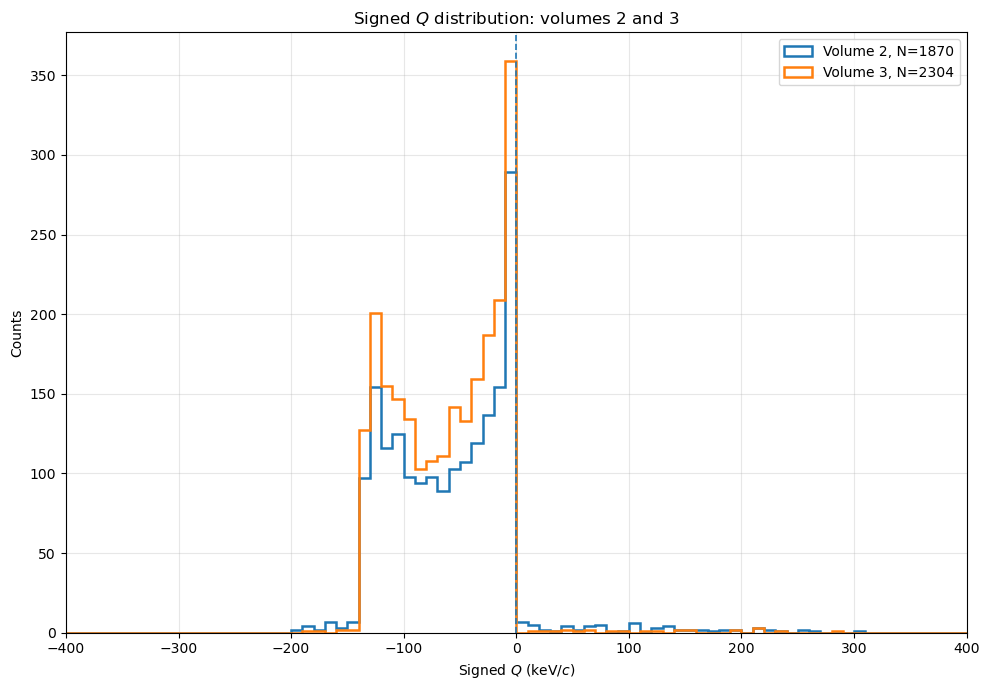

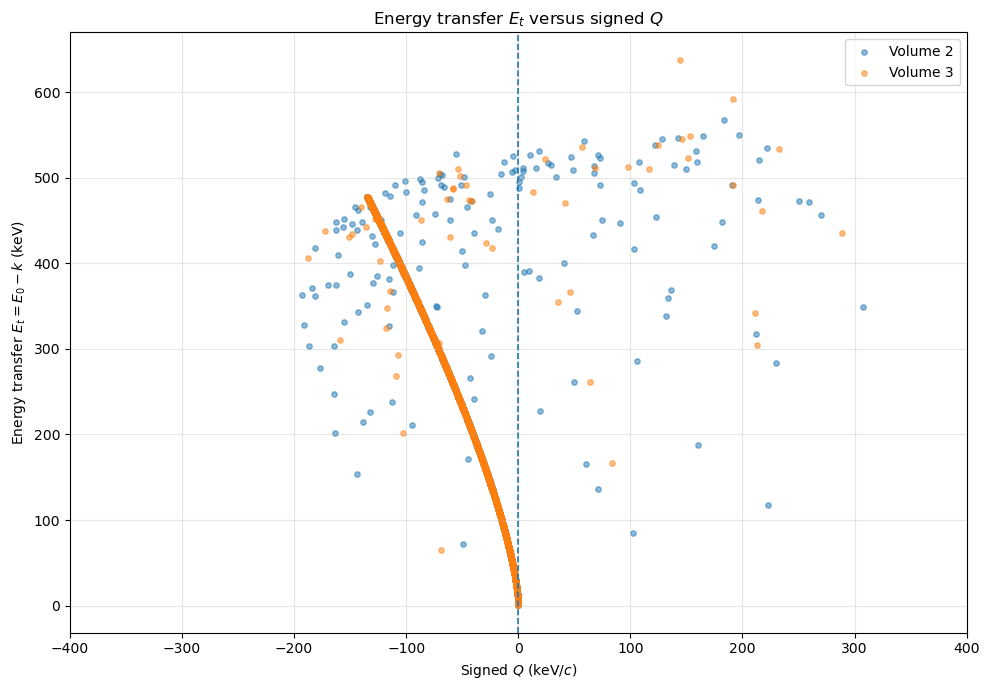

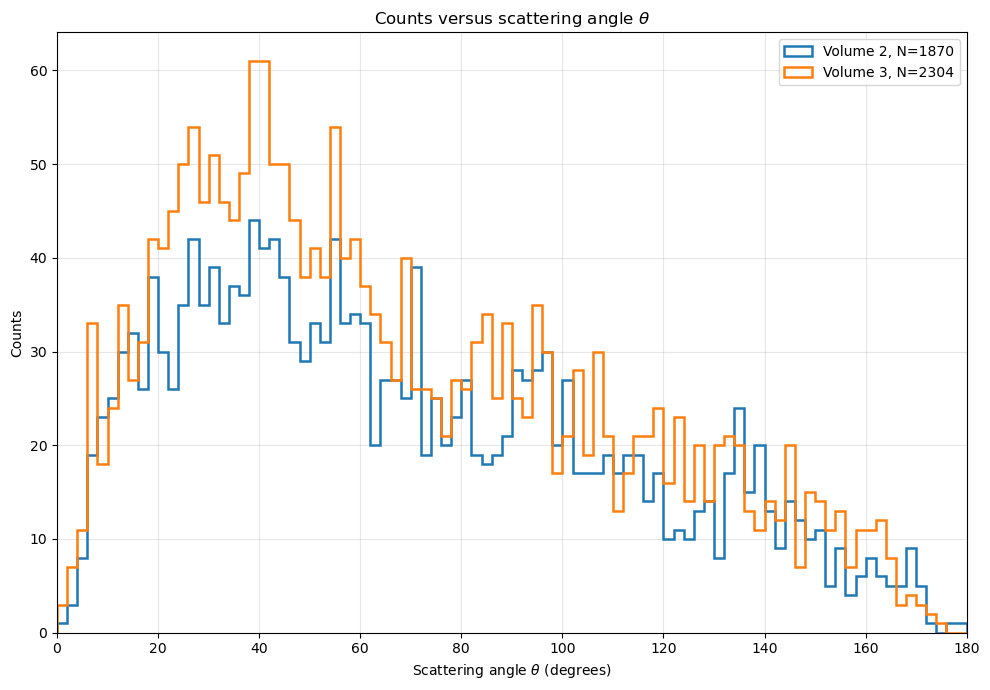

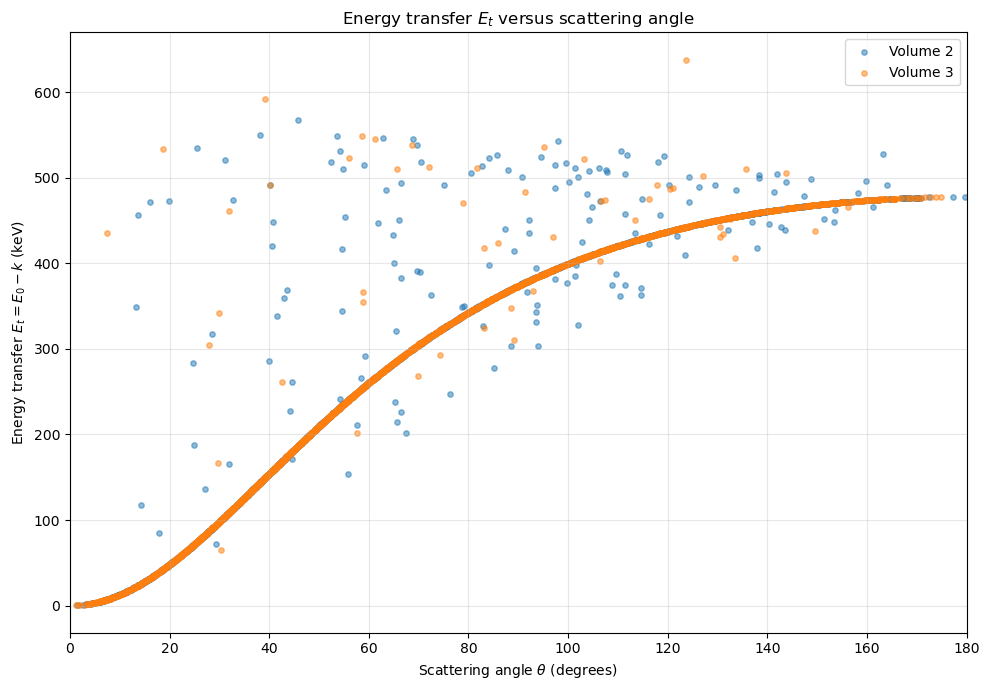

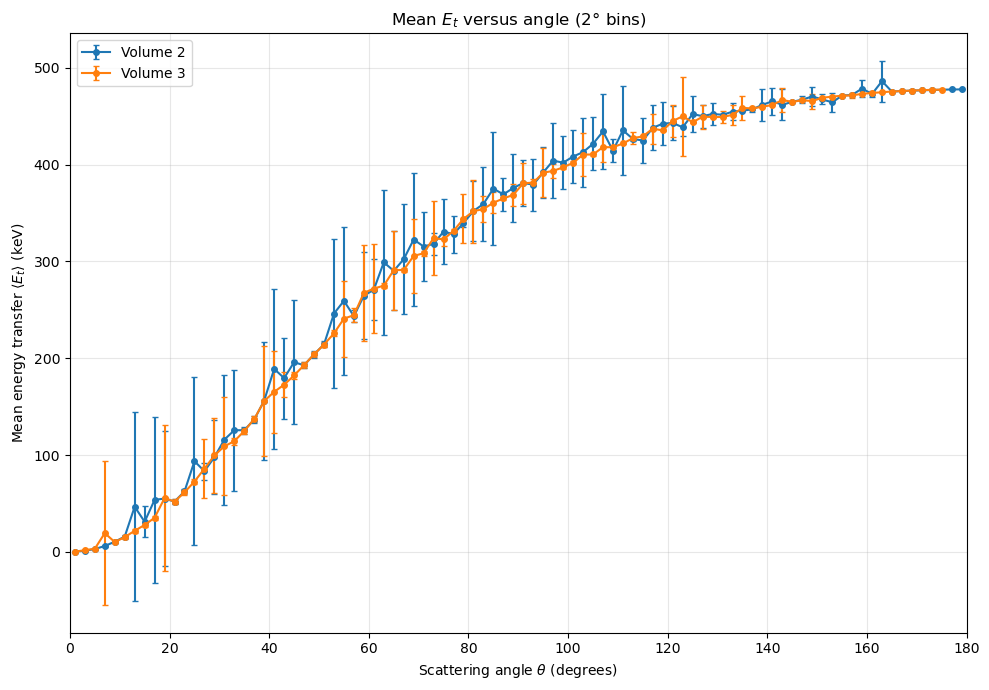

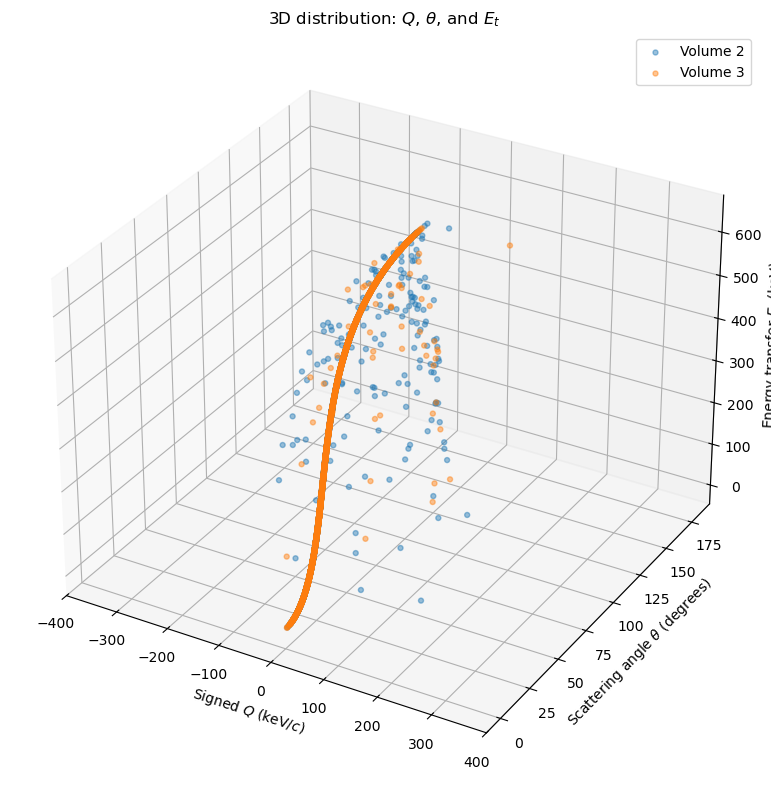


First calculated Q records:


,tree_entry,vector_index,vlm,pdg,pro,stp,E0_keV,k,Eprime_keV,Et_keV,...,Eprime_difference_keV,qc_keV_c,Q_keV_c,Abs_Q_keV_c,Q_au,Abs_Q_au,de,x,y,z
13,4,3,3,22,2013,3,662.0,189.930680,189.930680,472.069320,...,-1.060188e-05,839.823350,-132.676357,132.676357,-35.595071,35.595071,0.0,0.0,-1.637053,0.0
173,57,3,3,22,2013,3,662.0,348.702174,348.702174,313.297826,...,-1.291796e-05,646.796121,-75.878240,75.878240,-20.356991,20.356991,0.0,0.0,-0.610534,0.0
212,70,2,2,22,2013,2,662.0,656.264320,656.264320,5.735680,...,-4.450879e-07,76.777278,-0.214240,0.214240,-0.057477,0.057477,0.0,0.0,8.658919,0.0
230,75,3,3,22,2013,3,662.0,560.996324,560.996324,101.003676,...,-6.700068e-06,336.789666,-15.145557,15.145557,-4.063325,4.063325,0.0,0.0,-0.909895,0.0
235,76,3,3,22,2013,3,662.0,654.214698,654.214698,7.785302,...,-6.022512e-07,89.538668,-0.338459,0.338459,-0.090803,0.090803,0.0,0.0,0.447901,0.0
338,110,3,3,22,2013,3,662.0,621.541198,621.541198,40.458802,...,-2.973479e-06,207.329983,-3.947599,3.947599,-1.059082,1.059082,0.0,0.0,-1.831096,0.0
346,112,4,2,22,2013,4,662.0,295.137350,295.137350,366.862650,...,-1.280294e-05,713.807420,-94.274850,94.274850,-25.292524,25.292524,0.0,0.0,-7.730796,0.0
374,121,4,2,22,2013,4,662.0,473.338040,473.338040,188.661960,...,-1.055936e-05,477.917824,-37.237908,37.237908,-9.990371,9.990371,0.0,0.0,-8.894200,0.0
379,122,4,2,22,2013,4,662.0,574.777793,574.777793,87.222207,...,-5.928012e-06,311.044400,-12.229293,12.229293,-3.280935,3.280935,0.0,0.0,-5.917304,0.0
397,127,4,2,22,2013,4,662.0,496.961768,496.961768,165.038232,...,-9.698164e-06,442.613073,-30.769092,30.769092,-8.254885,8.254885,0.0,0.0,-2.983939,0.0



Volume 2 angular summary:


,volume,theta_bin_left_deg,theta_bin_right_deg,theta_bin_center_deg,counts,mean_theta_deg,std_theta_deg,mean_Eprime_keV,std_Eprime_keV,mean_Et_keV,std_Et_keV,mean_qc_keV_c,std_qc_keV_c,mean_Q_keV_c,std_Q_keV_c,mean_Abs_Q_keV_c,std_Abs_Q_keV_c,mean_Q_au,std_Q_au
0,2,0.0,2.0,1.0,1,1.498323,NaN,661.706901,NaN,0.293099,NaN,17.309894,NaN,-0.002481,NaN,0.002481,NaN,-0.000666,NaN
1,2,2.0,4.0,3.0,3,3.057938,0.393089,660.767788,0.305147,1.232212,0.305147,35.315459,4.535989,-0.021712,0.007750,0.021712,0.007750,-0.005825,0.002079
2,2,4.0,6.0,5.0,8,4.768870,0.428447,659.024010,0.554323,2.975990,0.554323,55.039003,4.932495,-0.081055,0.023587,0.081055,0.023587,-0.021746,0.006328
3,2,6.0,8.0,7.0,19,6.864125,0.623486,655.864307,1.100474,6.135693,1.100474,79.126276,7.154407,-0.239661,0.064133,0.239661,0.064133,-0.064297,0.017206
4,2,8.0,10.0,9.0,23,9.047477,0.551870,651.464961,1.255188,10.535039,1.255188,104.121568,6.301303,-0.534729,0.094681,0.534729,0.094681,-0.143460,0.025402
5,2,10.0,12.0,11.0,25,11.143191,0.501184,646.190275,1.368416,15.809725,1.368416,127.977283,5.688512,-0.978225,0.124896,0.978225,0.124896,-0.262443,0.033508
6,2,12.0,14.0,13.0,30,13.028750,0.607566,615.290331,97.698816,46.709669,97.698816,166.654021,68.896636,17.803339,73.731789,20.654729,72.958457,4.776368,19.781130
7,2,14.0,16.0,15.0,32,15.075313,0.620514,630.826346,15.892565,31.173654,15.892565,173.093009,7.327745,4.683460,39.722347,9.214059,38.895625,1.256502,10.656908
8,2,16.0,18.0,17.0,26,16.898475,0.609954,608.221648,85.760966,53.778352,85.760966,204.258124,57.024041,10.939300,54.665474,16.843604,53.082142,2.934850,14.665925
9,2,18.0,20.0,19.0,38,19.053734,0.559451,606.903458,69.698318,55.096542,69.698318,223.159777,44.642742,2.262376,41.337601,10.914992,39.896077,0.606961,11.090257



Volume 3 angular summary:


,volume,theta_bin_left_deg,theta_bin_right_deg,theta_bin_center_deg,counts,mean_theta_deg,std_theta_deg,mean_Eprime_keV,std_Eprime_keV,mean_Et_keV,std_Et_keV,mean_qc_keV_c,std_qc_keV_c,mean_Q_keV_c,std_Q_keV_c,mean_Abs_Q_keV_c,std_Abs_Q_keV_c,mean_Q_au,std_Q_au
0,3,0.0,2.0,1.0,3,1.575181,0.303685,661.668071,0.117903,0.331929,0.117903,18.197472,3.507679,-0.003088,0.001502,0.003088,0.001502,-0.000829,0.000403
1,3,2.0,4.0,3.0,7,3.663155,0.372373,660.237164,0.340505,1.762836,0.340505,42.296700,4.294796,-0.037023,0.010193,0.037023,0.010193,-0.009933,0.002735
2,3,4.0,6.0,5.0,11,5.011046,0.560650,658.702129,0.727494,3.297871,0.727494,57.826490,6.454320,-0.095057,0.031058,0.095057,0.031058,-0.025502,0.008332
3,3,6.0,8.0,7.0,33,7.024985,0.646345,642.601834,74.685388,19.398166,74.685388,91.628953,62.671731,8.491428,50.246618,8.986705,50.157707,2.278122,13.480412
4,3,8.0,10.0,9.0,18,8.918673,0.516957,651.761135,1.164837,10.238865,1.164837,102.651312,5.904107,-0.512153,0.086942,0.512153,0.086942,-0.137403,0.023325
5,3,10.0,12.0,11.0,24,10.953083,0.554217,646.704319,1.504640,15.295681,1.504640,125.818687,6.291889,-0.931824,0.136458,0.931824,0.136458,-0.249994,0.036610
6,3,12.0,14.0,13.0,35,13.166436,0.588318,640.162974,1.858244,21.837026,1.858244,150.847318,6.629093,-1.583245,0.198279,1.583245,0.198279,-0.424761,0.053195
7,3,14.0,16.0,15.0,27,14.956707,0.595408,634.133633,2.117560,27.866367,2.117560,170.931611,6.651462,-2.274456,0.257524,2.274456,0.257524,-0.610202,0.069090
8,3,16.0,18.0,17.0,31,16.950601,0.569963,626.699569,2.232294,35.300431,2.232294,193.104733,6.304841,-3.229446,0.303093,3.229446,0.303093,-0.866412,0.081315
9,3,18.0,20.0,19.0,42,19.063516,0.576102,606.376733,75.516763,55.623267,75.516763,224.176837,50.550983,1.167047,36.539855,9.895930,35.160181,0.313101,9.803094



FILES CREATED

File:
/root/geant4/detector/Lung_ICRP/lung1_tissueTumor_all_gamma_data.xlsx
Exists:
True
Size:
15951355 bytes

File:
/root/geant4/detector/Lung_ICRP/lung1_volume2_volume3_Q_detailed_keV_c.xlsx
Exists:
True
Size:
2063311 bytes

File:
/root/geant4/detector/Lung_ICRP/lung1_volume2_volume3_Q_theta_summary_keV_c.xlsx
Exists:
True
Size:
73026 bytes

File:
/root/geant4/detector/Lung_ICRP/volume2_Q_detailed_keV_c.csv
Exists:
True
Size:
733318 bytes

File:
/root/geant4/detector/Lung_ICRP/volume3_Q_detailed_keV_c.csv
Exists:
True
Size:
901749 bytes

File:
/root/geant4/detector/Lung_ICRP/volume2_Q_theta_summary_keV_c.csv
Exists:
True
Size:
24957 bytes

File:
/root/geant4/detector/Lung_ICRP/volume3_Q_theta_summary_keV_c.csv
Exists:
True
Size:
25222 bytes

File:
/root/geant4/detector/Lung_ICRP/volume2_volume3_Q_theta_summary_keV_c.csv
Exists:
True
Size:
49918 bytes


In [6]:
import os
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. WORKING DIRECTORY AND ROOT FILE
# =====================================================
working_directory = "/root/geant4/detector/Lung_ICRP"
os.chdir(working_directory)

file_path = "lung1_tissueTumor.root"
tree_name = "t"

# Extract gamma records from these volumes
selected_volumes = [2, 3, 4, 5]
selected_pdg = 22

# =====================================================
# 2. PHYSICS SETTINGS
# =====================================================
E0 = 662.0                 # incident gamma energy, keV
ME_C2 = 510.99895          # electron rest energy, keV
P_AU = 3.72738             # 1 a.u. momentum = 3.72738 keV/c

# Incident gamma direction:
# /gps/direction 0 -1 0
incident_direction = np.array([0.0, -1.0, 0.0])

# Geant4 Compton process code
compton_process = 2013

# True:
#     Q analysis uses only pdg == 22 and pro == 2013.
#
# False:
#     Q analysis uses all gamma records in volumes 2 and 3.
use_compton_only = True

# =====================================================
# 3. BINNING AND PLOT SETTINGS
# =====================================================

# Theta bin width
theta_bin_width_deg = 2.0

# Q histogram bin width in keV/c
q_bin_width_keV_c = 10.0

# Q display range in keV/c
q_plot_min_keV_c = -400.0
q_plot_max_keV_c = 400.0

# Theta display range
theta_plot_min_deg = 0.0
theta_plot_max_deg = 180.0

# Remove extreme Q values only from plots.
# All valid Q values remain in Excel and CSV files.
restrict_plot_Q = True
plot_abs_Q_limit_keV_c = 400.0

# =====================================================
# 4. OUTPUT FILE NAMES
# =====================================================
original_excel = "lung1_tissueTumor_all_gamma_data.xlsx"

q_detailed_excel = (
    "lung1_volume2_volume3_Q_detailed_keV_c.xlsx"
)

q_summary_excel = (
    "lung1_volume2_volume3_Q_theta_summary_keV_c.xlsx"
)

volume2_detailed_csv = "volume2_Q_detailed_keV_c.csv"
volume3_detailed_csv = "volume3_Q_detailed_keV_c.csv"

volume2_summary_csv = "volume2_Q_theta_summary_keV_c.csv"
volume3_summary_csv = "volume3_Q_theta_summary_keV_c.csv"

combined_summary_csv = (
    "volume2_volume3_Q_theta_summary_keV_c.csv"
)

print("Working directory:")
print(os.getcwd())

print("\nInput ROOT file:")
print(os.path.abspath(file_path))

# =====================================================
# 5. OPEN ROOT FILE
# =====================================================
if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"ROOT file was not found:\n"
        f"{os.path.abspath(file_path)}"
    )

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise OSError(
        f"Could not open ROOT file:\n"
        f"{os.path.abspath(file_path)}"
    )

tree = root_file.Get(tree_name)

if not tree:
    root_file.Close()
    raise KeyError(
        f"TTree '{tree_name}' was not found."
    )

print("\nTotal TTree entries:")
print(tree.GetEntries())

# =====================================================
# 6. CHECK AVAILABLE BRANCHES
# =====================================================
available_branches = {
    branch.GetName()
    for branch in tree.GetListOfBranches()
}

required_branches = [
    "vlm",
    "pdg",
    "pro",
    "stp",
    "k",
    "de",
    "x",
    "y",
    "z",
    "px",
    "py",
    "pz"
]

missing_branches = [
    branch
    for branch in required_branches
    if branch not in available_branches
]

if missing_branches:
    root_file.Close()

    raise KeyError(
        f"Missing ROOT branches:\n"
        f"{missing_branches}\n\n"
        f"Available branches:\n"
        f"{sorted(available_branches)}"
    )

# et is optional because the et vector may be empty
has_et_branch = "et" in available_branches

print("\net branch exists:", has_et_branch)

# =====================================================
# 7. SAFE VECTOR READER
# =====================================================
def safe_value(vector, index, default=np.nan):
    """
    Return vector[index] if the element exists.
    Otherwise return the specified default.
    """
    if index < len(vector):
        return vector[index]

    return default

# =====================================================
# 8. EXTRACT GAMMA RECORDS
# =====================================================
original_columns = [
    "tree_entry",
    "vector_index",
    "vlm",
    "pdg",
    "pro",
    "stp",
    "k",
    "et_root",
    "de",
    "x",
    "y",
    "z",
    "px",
    "py",
    "pz"
]

volume_data = {
    volume: []
    for volume in selected_volumes
}

combined_data = []

for tree_entry, event in enumerate(tree):

    # pdg is the main vector defining the number of records
    number_of_records = len(event.pdg)

    for vector_index in range(number_of_records):

        pdg_value = int(event.pdg[vector_index])

        # Keep only gamma records
        if pdg_value != selected_pdg:
            continue

        # The volume vector must have this element
        if vector_index >= len(event.vlm):
            continue

        volume_value = int(event.vlm[vector_index])

        # Keep only volumes 2, 3, 4 and 5
        if volume_value not in selected_volumes:
            continue

        if has_et_branch:
            et_root_value = float(
                safe_value(
                    event.et,
                    vector_index,
                    np.nan
                )
            )
        else:
            et_root_value = np.nan

        row = {
            "tree_entry": int(tree_entry),
            "vector_index": int(vector_index),

            "vlm": volume_value,
            "pdg": pdg_value,

            "pro": int(
                safe_value(
                    event.pro,
                    vector_index,
                    -1
                )
            ),

            "stp": int(
                safe_value(
                    event.stp,
                    vector_index,
                    -1
                )
            ),

            "k": float(
                safe_value(
                    event.k,
                    vector_index,
                    np.nan
                )
            ),

            "et_root": et_root_value,

            "de": float(
                safe_value(
                    event.de,
                    vector_index,
                    np.nan
                )
            ),

            "x": float(
                safe_value(
                    event.x,
                    vector_index,
                    np.nan
                )
            ),

            "y": float(
                safe_value(
                    event.y,
                    vector_index,
                    np.nan
                )
            ),

            "z": float(
                safe_value(
                    event.z,
                    vector_index,
                    np.nan
                )
            ),

            "px": float(
                safe_value(
                    event.px,
                    vector_index,
                    np.nan
                )
            ),

            "py": float(
                safe_value(
                    event.py,
                    vector_index,
                    np.nan
                )
            ),

            "pz": float(
                safe_value(
                    event.pz,
                    vector_index,
                    np.nan
                )
            )
        }

        volume_data[volume_value].append(row)
        combined_data.append(row)

root_file.Close()

# =====================================================
# 9. CREATE ORIGINAL DATAFRAMES
# =====================================================
volume_frames = {
    volume: pd.DataFrame(
        volume_data[volume],
        columns=original_columns
    )
    for volume in selected_volumes
}

df_all = pd.DataFrame(
    combined_data,
    columns=original_columns
)

print("\nExtracted gamma records:")

for volume in selected_volumes:
    print(
        f"Volume {volume}: "
        f"{len(volume_frames[volume])}"
    )

print("All selected volumes:", len(df_all))

# =====================================================
# 10. SAVE ORIGINAL GAMMA DATA
# =====================================================
with pd.ExcelWriter(
    original_excel,
    engine="openpyxl"
) as writer:

    for volume in selected_volumes:

        volume_frames[volume].to_excel(
            writer,
            sheet_name=f"Volume_{volume}",
            index=False
        )

    df_all.to_excel(
        writer,
        sheet_name="All_Volumes",
        index=False
    )

print("\nOriginal gamma workbook saved:")
print(os.path.abspath(original_excel))

# =====================================================
# 11. SELECT VOLUME 2 AND VOLUME 3
# =====================================================
df_q = df_all[
    (df_all["vlm"].isin([2, 3])) &
    (df_all["pdg"] == 22)
].copy()

if use_compton_only:

    df_q = df_q[
        df_q["pro"] == compton_process
    ].copy()

print("\nQ-analysis records before cleaning:")
print(len(df_q))

# =====================================================
# 12. CONVERT COLUMNS TO NUMERIC
# =====================================================
numeric_columns = [
    "tree_entry",
    "vector_index",
    "vlm",
    "pdg",
    "pro",
    "stp",
    "k",
    "de",
    "x",
    "y",
    "z",
    "px",
    "py",
    "pz"
]

for column in numeric_columns:

    df_q[column] = pd.to_numeric(
        df_q[column],
        errors="coerce"
    )

# Remove records missing the required quantities
df_q = df_q.dropna(
    subset=[
        "k",
        "px",
        "py",
        "pz",
        "vlm"
    ]
).copy()

# Keep physically useful gamma energies
df_q = df_q[
    (df_q["k"] > 0.0) &
    (df_q["k"] <= E0)
].copy()

# =====================================================
# 13. MOMENTUM OR DIRECTION MAGNITUDE
# =====================================================
df_q["p_magnitude"] = np.sqrt(
    df_q["px"]**2
    + df_q["py"]**2
    + df_q["pz"]**2
)

df_q = df_q[
    df_q["p_magnitude"] > 0.0
].copy()

# =====================================================
# 14. CALCULATE SCATTERING ANGLE
#
# Incident direction = (0, -1, 0)
#
# cos(theta) =
# p_incident dot p_outgoing / |p_outgoing|
#
# Therefore:
# cos(theta) = -py / sqrt(px^2 + py^2 + pz^2)
# =====================================================
df_q["cos_theta"] = (
    incident_direction[0] * df_q["px"]
    + incident_direction[1] * df_q["py"]
    + incident_direction[2] * df_q["pz"]
) / df_q["p_magnitude"]

df_q["cos_theta"] = np.clip(
    df_q["cos_theta"],
    -1.0,
    1.0
)

df_q["theta_rad"] = np.arccos(
    df_q["cos_theta"]
)

df_q["theta_deg"] = np.degrees(
    df_q["theta_rad"]
)

# =====================================================
# 15. ENERGY CALCULATIONS
# =====================================================
df_q["E0_keV"] = E0

# The ROOT branch k is treated as scattered energy E'
df_q["Eprime_keV"] = df_q["k"]

# Energy transfer
df_q["Et_keV"] = (
    E0 - df_q["Eprime_keV"]
)

# Ideal free-electron Compton scattered energy
df_q["Eprime_free_keV"] = E0 / (
    1.0
    + (E0 / ME_C2)
    * (1.0 - df_q["cos_theta"])
)

# Ideal free-electron energy transfer
df_q["Et_free_keV"] = (
    E0 - df_q["Eprime_free_keV"]
)

# Difference between simulated and ideal E'
df_q["Eprime_difference_keV"] = (
    df_q["Eprime_keV"]
    - df_q["Eprime_free_keV"]
)

# =====================================================
# 16. PHOTON MOMENTUM TRANSFER qc
#
# qc = sqrt(
#        E0^2 + E'^2
#        - 2 E0 E' cos(theta)
#      )
#
# Numerical unit: keV/c
# =====================================================
df_q["qc_squared"] = (
    E0**2
    + df_q["Eprime_keV"]**2
    - 2.0
    * E0
    * df_q["Eprime_keV"]
    * df_q["cos_theta"]
)

# Remove very small negative values caused by rounding
df_q["qc_squared"] = np.clip(
    df_q["qc_squared"],
    0.0,
    None
)

df_q["qc_keV_c"] = np.sqrt(
    df_q["qc_squared"]
)

# Q contains division by qc
df_q = df_q[
    df_q["qc_keV_c"] > 0.0
].copy()

# =====================================================
# 17. CALCULATE SIGNED Q
#
# Q = (m_e c^2 / qc)
#     [Et - qc^2/(2 m_e c^2)]
#
# Unit: keV/c
# =====================================================
df_q["Q_keV_c"] = (
    ME_C2 / df_q["qc_keV_c"]
) * (
    df_q["Et_keV"]
    - (
        df_q["qc_keV_c"]**2
        / (2.0 * ME_C2)
    )
)

# Optional atomic-unit columns
df_q["Q_au"] = (
    df_q["Q_keV_c"] / P_AU
)

df_q["Abs_Q_keV_c"] = np.abs(
    df_q["Q_keV_c"]
)

df_q["Abs_Q_au"] = np.abs(
    df_q["Q_au"]
)

# Remove invalid values
df_q = df_q.replace(
    [np.inf, -np.inf],
    np.nan
)

df_q = df_q.dropna(
    subset=[
        "theta_deg",
        "Et_keV",
        "qc_keV_c",
        "Q_keV_c"
    ]
).copy()

# =====================================================
# 18. SEPARATE VOLUME 2 AND VOLUME 3
# =====================================================
df_vlm2 = df_q[
    df_q["vlm"] == 2
].copy()

df_vlm3 = df_q[
    df_q["vlm"] == 3
].copy()

print("\nUsable calculated records:")
print("Volume 2:", len(df_vlm2))
print("Volume 3:", len(df_vlm3))

# =====================================================
# 19. DETAILED OUTPUT COLUMNS
# =====================================================
detailed_columns = [
    "tree_entry",
    "vector_index",
    "vlm",
    "pdg",
    "pro",
    "stp",

    "E0_keV",
    "k",
    "Eprime_keV",
    "Et_keV",

    "px",
    "py",
    "pz",
    "p_magnitude",

    "cos_theta",
    "theta_rad",
    "theta_deg",

    "Eprime_free_keV",
    "Et_free_keV",
    "Eprime_difference_keV",

    "qc_keV_c",
    "Q_keV_c",
    "Abs_Q_keV_c",

    # Atomic-unit columns are also kept for comparison
    "Q_au",
    "Abs_Q_au",

    "de",
    "x",
    "y",
    "z"
]

detailed_columns = [
    column
    for column in detailed_columns
    if column in df_q.columns
]

# =====================================================
# 20. SAVE DETAILED Q FILES
# =====================================================
with pd.ExcelWriter(
    q_detailed_excel,
    engine="openpyxl"
) as writer:

    df_vlm2[detailed_columns].to_excel(
        writer,
        sheet_name="Volume_2",
        index=False
    )

    df_vlm3[detailed_columns].to_excel(
        writer,
        sheet_name="Volume_3",
        index=False
    )

    df_q[detailed_columns].to_excel(
        writer,
        sheet_name="Combined_Vlm2_Vlm3",
        index=False
    )

df_vlm2[detailed_columns].to_csv(
    volume2_detailed_csv,
    index=False
)

df_vlm3[detailed_columns].to_csv(
    volume3_detailed_csv,
    index=False
)

print("\nDetailed Q workbook saved:")
print(os.path.abspath(q_detailed_excel))

# =====================================================
# 21. CREATE THETA-BIN SUMMARY
# =====================================================
theta_edges = np.arange(
    theta_plot_min_deg,
    theta_plot_max_deg + theta_bin_width_deg,
    theta_bin_width_deg
)

def create_theta_summary(dataframe, volume):
    """
    Create a fixed-angular-bin summary for one volume.
    """

    data = dataframe.copy()

    data["theta_bin"] = pd.cut(
        data["theta_deg"],
        bins=theta_edges,
        right=False,
        include_lowest=True
    )

    grouped = data.groupby(
        "theta_bin",
        observed=False
    ).agg(
        counts=("theta_deg", "size"),

        mean_theta_deg=("theta_deg", "mean"),
        std_theta_deg=("theta_deg", "std"),

        mean_Eprime_keV=("Eprime_keV", "mean"),
        std_Eprime_keV=("Eprime_keV", "std"),

        mean_Et_keV=("Et_keV", "mean"),
        std_Et_keV=("Et_keV", "std"),

        mean_qc_keV_c=("qc_keV_c", "mean"),
        std_qc_keV_c=("qc_keV_c", "std"),

        mean_Q_keV_c=("Q_keV_c", "mean"),
        std_Q_keV_c=("Q_keV_c", "std"),

        mean_Abs_Q_keV_c=("Abs_Q_keV_c", "mean"),
        std_Abs_Q_keV_c=("Abs_Q_keV_c", "std"),

        mean_Q_au=("Q_au", "mean"),
        std_Q_au=("Q_au", "std")
    ).reset_index()

    grouped["volume"] = volume

    grouped["theta_bin_left_deg"] = (
        grouped["theta_bin"]
        .apply(
            lambda interval:
            interval.left
            if pd.notna(interval)
            else np.nan
        )
        .astype(float)
    )

    grouped["theta_bin_right_deg"] = (
        grouped["theta_bin"]
        .apply(
            lambda interval:
            interval.right
            if pd.notna(interval)
            else np.nan
        )
        .astype(float)
    )

    grouped["theta_bin_center_deg"] = 0.5 * (
        grouped["theta_bin_left_deg"]
        + grouped["theta_bin_right_deg"]
    )

    grouped = grouped.drop(
        columns=["theta_bin"]
    )

    summary_columns = [
        "volume",
        "theta_bin_left_deg",
        "theta_bin_right_deg",
        "theta_bin_center_deg",
        "counts",

        "mean_theta_deg",
        "std_theta_deg",

        "mean_Eprime_keV",
        "std_Eprime_keV",

        "mean_Et_keV",
        "std_Et_keV",

        "mean_qc_keV_c",
        "std_qc_keV_c",

        "mean_Q_keV_c",
        "std_Q_keV_c",

        "mean_Abs_Q_keV_c",
        "std_Abs_Q_keV_c",

        "mean_Q_au",
        "std_Q_au"
    ]

    return grouped[summary_columns]

summary_vlm2 = create_theta_summary(
    df_vlm2,
    volume=2
)

summary_vlm3 = create_theta_summary(
    df_vlm3,
    volume=3
)

summary_combined = pd.concat(
    [summary_vlm2, summary_vlm3],
    ignore_index=True
)

# =====================================================
# 22. SAVE SUMMARY FILES
# =====================================================
with pd.ExcelWriter(
    q_summary_excel,
    engine="openpyxl"
) as writer:

    summary_vlm2.to_excel(
        writer,
        sheet_name="Volume_2_Summary",
        index=False
    )

    summary_vlm3.to_excel(
        writer,
        sheet_name="Volume_3_Summary",
        index=False
    )

    summary_combined.to_excel(
        writer,
        sheet_name="Combined_Summary",
        index=False
    )

summary_vlm2.to_csv(
    volume2_summary_csv,
    index=False
)

summary_vlm3.to_csv(
    volume3_summary_csv,
    index=False
)

summary_combined.to_csv(
    combined_summary_csv,
    index=False
)

print("\nSummary workbook saved:")
print(os.path.abspath(q_summary_excel))

# =====================================================
# 23. PREPARE DATA USED IN PLOTS
# =====================================================
plot_vlm2 = df_vlm2.copy()
plot_vlm3 = df_vlm3.copy()

if restrict_plot_Q:

    plot_vlm2 = plot_vlm2[
        np.abs(plot_vlm2["Q_keV_c"])
        <= plot_abs_Q_limit_keV_c
    ].copy()

    plot_vlm3 = plot_vlm3[
        np.abs(plot_vlm3["Q_keV_c"])
        <= plot_abs_Q_limit_keV_c
    ].copy()

print("\nRecords used in plots:")
print("Volume 2:", len(plot_vlm2))
print("Volume 3:", len(plot_vlm3))

# =====================================================
# 24. PLOT 1
# Q ON X-AXIS, COUNTS ON Y-AXIS
# =====================================================
q_bins_keV_c = np.arange(
    q_plot_min_keV_c,
    q_plot_max_keV_c + q_bin_width_keV_c,
    q_bin_width_keV_c
)

plt.figure(figsize=(10, 7))

plt.hist(
    plot_vlm2["Q_keV_c"],
    bins=q_bins_keV_c,
    histtype="step",
    linewidth=1.8,
    label=f"Volume 2, N={len(plot_vlm2)}"
)

plt.hist(
    plot_vlm3["Q_keV_c"],
    bins=q_bins_keV_c,
    histtype="step",
    linewidth=1.8,
    label=f"Volume 3, N={len(plot_vlm3)}"
)

plt.axvline(
    0.0,
    linestyle="--",
    linewidth=1.2
)

plt.xlim(
    q_plot_min_keV_c,
    q_plot_max_keV_c
)

plt.xlabel(r"Signed $Q$ (keV/$c$)")
plt.ylabel("Counts")

plt.title(
    r"Signed $Q$ distribution: volumes 2 and 3"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 25. PLOT 2
# Q ON X-AXIS, Et ON Y-AXIS
# =====================================================
plt.figure(figsize=(10, 7))

plt.scatter(
    plot_vlm2["Q_keV_c"],
    plot_vlm2["Et_keV"],
    s=15,
    alpha=0.5,
    label="Volume 2"
)

plt.scatter(
    plot_vlm3["Q_keV_c"],
    plot_vlm3["Et_keV"],
    s=15,
    alpha=0.5,
    label="Volume 3"
)

plt.axvline(
    0.0,
    linestyle="--",
    linewidth=1.2
)

if restrict_plot_Q:
    plt.xlim(
        -plot_abs_Q_limit_keV_c,
        plot_abs_Q_limit_keV_c
    )

plt.xlabel(r"Signed $Q$ (keV/$c$)")
plt.ylabel(r"Energy transfer $E_t=E_0-k$ (keV)")

plt.title(
    r"Energy transfer $E_t$ versus signed $Q$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 26. PLOT 3
# THETA ON X-AXIS, COUNTS ON Y-AXIS
# =====================================================
plt.figure(figsize=(10, 7))

plt.hist(
    plot_vlm2["theta_deg"],
    bins=theta_edges,
    histtype="step",
    linewidth=1.8,
    label=f"Volume 2, N={len(plot_vlm2)}"
)

plt.hist(
    plot_vlm3["theta_deg"],
    bins=theta_edges,
    histtype="step",
    linewidth=1.8,
    label=f"Volume 3, N={len(plot_vlm3)}"
)

plt.xlim(
    theta_plot_min_deg,
    theta_plot_max_deg
)

plt.xlabel(r"Scattering angle $\theta$ (degrees)")
plt.ylabel("Counts")

plt.title(
    r"Counts versus scattering angle $\theta$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 27. PLOT 4
# THETA ON X-AXIS, Et ON Y-AXIS
# EVENT-BY-EVENT SCATTER
# =====================================================
plt.figure(figsize=(10, 7))

plt.scatter(
    plot_vlm2["theta_deg"],
    plot_vlm2["Et_keV"],
    s=15,
    alpha=0.5,
    label="Volume 2"
)

plt.scatter(
    plot_vlm3["theta_deg"],
    plot_vlm3["Et_keV"],
    s=15,
    alpha=0.5,
    label="Volume 3"
)

plt.xlim(
    theta_plot_min_deg,
    theta_plot_max_deg
)

plt.xlabel(r"Scattering angle $\theta$ (degrees)")
plt.ylabel(r"Energy transfer $E_t=E_0-k$ (keV)")

plt.title(
    r"Energy transfer $E_t$ versus scattering angle"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 28. PLOT 5
# THETA ON X-AXIS, MEAN Et ON Y-AXIS
# BINNED ANGULAR SUMMARY
# =====================================================
valid_summary_vlm2 = summary_vlm2[
    summary_vlm2["counts"] > 0
].copy()

valid_summary_vlm3 = summary_vlm3[
    summary_vlm3["counts"] > 0
].copy()

plt.figure(figsize=(10, 7))

plt.errorbar(
    valid_summary_vlm2["theta_bin_center_deg"],
    valid_summary_vlm2["mean_Et_keV"],
    yerr=valid_summary_vlm2["std_Et_keV"],
    fmt="o-",
    markersize=4,
    capsize=2,
    label="Volume 2"
)

plt.errorbar(
    valid_summary_vlm3["theta_bin_center_deg"],
    valid_summary_vlm3["mean_Et_keV"],
    yerr=valid_summary_vlm3["std_Et_keV"],
    fmt="o-",
    markersize=4,
    capsize=2,
    label="Volume 3"
)

plt.xlim(
    theta_plot_min_deg,
    theta_plot_max_deg
)

plt.xlabel(r"Scattering angle $\theta$ (degrees)")
plt.ylabel(r"Mean energy transfer $\langle E_t\rangle$ (keV)")

plt.title(
    r"Mean $E_t$ versus angle "
    f"({theta_bin_width_deg:.0f}° bins)"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 29. 3D PLOT
#
# x-axis = Q in keV/c
# y-axis = theta
# z-axis = Et
# =====================================================
fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    plot_vlm2["Q_keV_c"],
    plot_vlm2["theta_deg"],
    plot_vlm2["Et_keV"],
    s=13,
    alpha=0.45,
    label="Volume 2"
)

ax.scatter(
    plot_vlm3["Q_keV_c"],
    plot_vlm3["theta_deg"],
    plot_vlm3["Et_keV"],
    s=13,
    alpha=0.45,
    label="Volume 3"
)

ax.set_xlabel(r"Signed $Q$ (keV/$c$)")
ax.set_ylabel(r"Scattering angle $\theta$ (degrees)")
ax.set_zlabel(r"Energy transfer $E_t$ (keV)")

ax.set_title(
    r"3D distribution: $Q$, $\theta$, and $E_t$"
)

if restrict_plot_Q:
    ax.set_xlim(
        -plot_abs_Q_limit_keV_c,
        plot_abs_Q_limit_keV_c
    )

ax.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 30. DISPLAY TABLES IN JUPYTER
# =====================================================
print("\nFirst calculated Q records:")

display(
    df_q[detailed_columns].head(15)
)

print("\nVolume 2 angular summary:")

display(
    summary_vlm2.head(15)
)

print("\nVolume 3 angular summary:")

display(
    summary_vlm3.head(15)
)

# =====================================================
# 31. FINAL OUTPUT INFORMATION
# =====================================================
print("\n" + "=" * 70)
print("FILES CREATED")
print("=" * 70)

output_files = [
    original_excel,
    q_detailed_excel,
    q_summary_excel,
    volume2_detailed_csv,
    volume3_detailed_csv,
    volume2_summary_csv,
    volume3_summary_csv,
    combined_summary_csv
]

for output_file in output_files:

    full_path = os.path.abspath(output_file)

    print("\nFile:")
    print(full_path)

    print("Exists:")
    print(os.path.exists(full_path))

    if os.path.exists(full_path):

        print("Size:")
        print(
            os.path.getsize(full_path),
            "bytes"
        )

Detector records before numerical cleaning: 1146

Usable detector records:
Volume 4: 634
Volume 5: 457

Detailed Excel file:
/root/geant4/detector/Lung_ICRP/volume4_volume5_theta_Et_detailed.xlsx

Summary Excel file:
/root/geant4/detector/Lung_ICRP/volume4_volume5_theta_Et_summary.xlsx


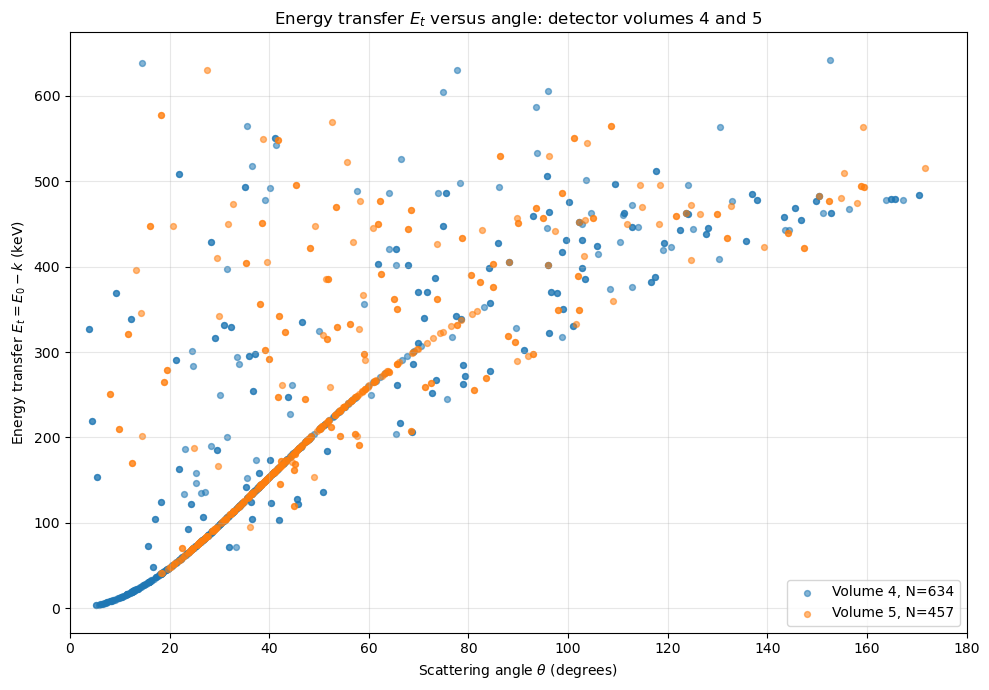

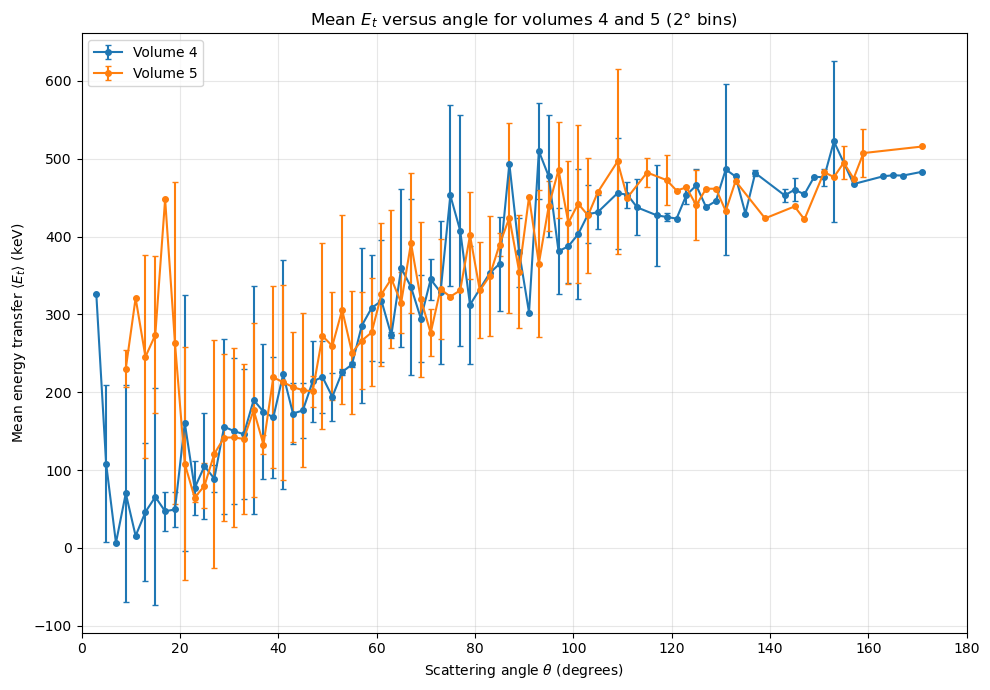

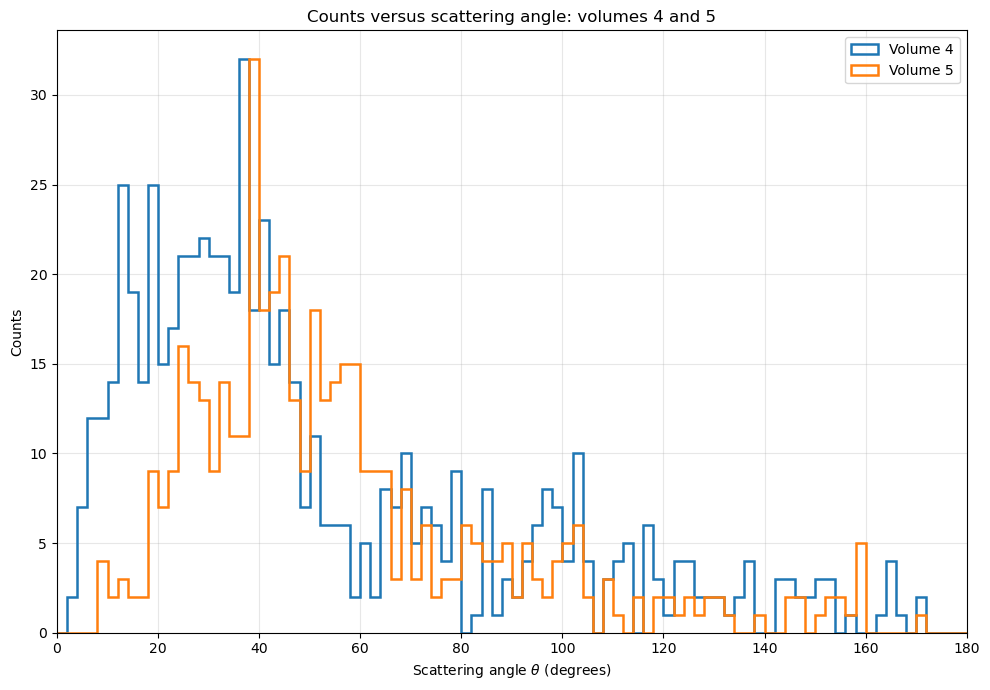

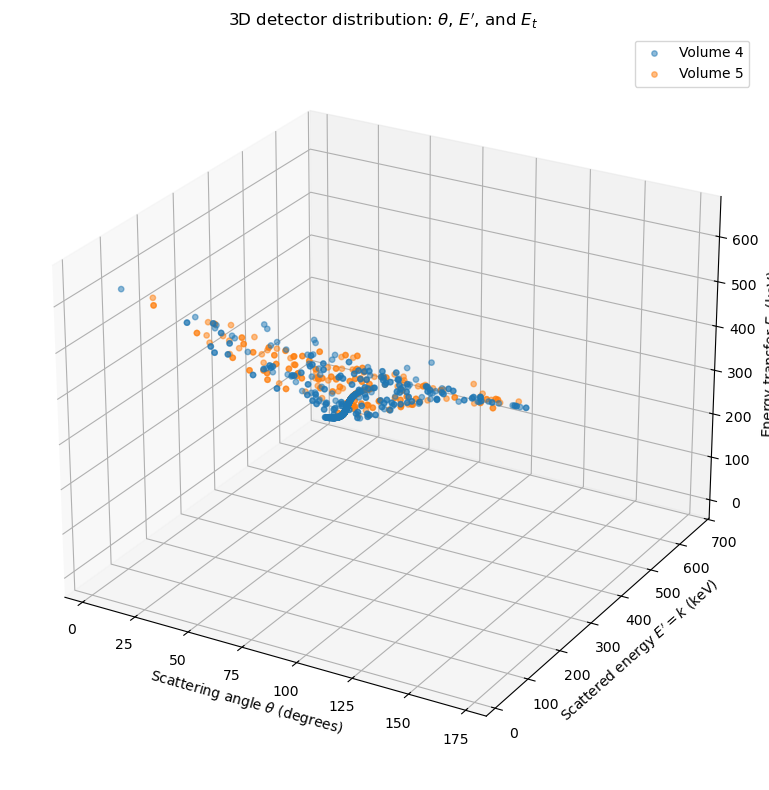


Volume 4 summary:


,volume,theta_bin_left_deg,theta_bin_right_deg,theta_bin_center_deg,counts,mean_theta_deg,std_theta_deg,mean_Eprime_keV,std_Eprime_keV,mean_Et_keV,std_Et_keV,min_Et_keV,max_Et_keV
0,4,0.0,2.0,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,2.0,4.0,3.0,2,3.787824,0.000000,335.377385,0.000000,326.622615,0.000000,326.622615,326.622615
2,4,4.0,6.0,5.0,7,5.183717,0.497893,553.530680,101.453511,108.469320,101.453511,3.487823,219.655160
3,4,6.0,8.0,7.0,12,7.071381,0.641741,655.494075,1.154091,6.505925,1.154091,4.777673,8.230559
4,4,8.0,10.0,9.0,12,9.013026,0.568280,591.842371,139.597152,70.157629,139.597152,8.606681,369.004721
5,4,10.0,12.0,11.0,14,11.027763,0.512268,646.506625,1.389500,15.493375,1.389500,13.370593,17.383871
6,4,12.0,14.0,13.0,25,12.793157,0.521088,615.757731,88.146208,46.242269,88.146208,18.279934,339.074616
7,4,14.0,16.0,15.0,19,15.241206,0.645672,596.429752,139.485386,65.570248,139.485386,24.551210,638.711390
8,4,16.0,18.0,17.0,14,16.922557,0.549008,614.900479,25.118707,47.099521,25.118707,31.798919,105.095584
9,4,18.0,20.0,19.0,25,18.773842,0.577483,612.574180,22.689327,49.425820,22.689327,39.733839,124.406736



Volume 5 summary:


,volume,theta_bin_left_deg,theta_bin_right_deg,theta_bin_center_deg,counts,mean_theta_deg,std_theta_deg,mean_Eprime_keV,std_Eprime_keV,mean_Et_keV,std_Et_keV,min_Et_keV,max_Et_keV
0,5,0.0,2.0,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5,2.0,4.0,3.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,4.0,6.0,5.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,6.0,8.0,7.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,8.0,10.0,9.0,4,8.996870,1.087192,431.559562,24.090844,230.440438,24.090844,209.577155,251.303722
5,5,10.0,12.0,11.0,2,11.602020,0.000000,340.973923,0.000000,321.026077,0.000000,321.026077,321.026077
6,5,12.0,14.0,13.0,3,12.791946,0.412568,416.519473,130.527592,245.480527,130.527592,170.120386,396.200807
7,5,14.0,16.0,15.0,2,14.356068,0.144557,388.306183,100.964709,273.693817,100.964709,202.300986,345.086647
8,5,16.0,18.0,17.0,2,16.141386,0.000000,213.999046,0.000000,448.000954,0.000000,448.000954,448.000954
9,5,18.0,20.0,19.0,9,18.866996,0.524411,398.632130,207.093442,263.367870,207.093442,40.918464,577.053402



Saved plot files:
/root/geant4/detector/Lung_ICRP/volume4_volume5_theta_vs_Et.png exists: True
/root/geant4/detector/Lung_ICRP/volume4_volume5_theta_vs_Et.pdf exists: True
/root/geant4/detector/Lung_ICRP/volume4_volume5_theta_vs_Et.svg exists: True
/root/geant4/detector/Lung_ICRP/volume4_volume5_mean_Et_vs_theta.png exists: True
/root/geant4/detector/Lung_ICRP/volume4_volume5_theta_Et_k_3D.png exists: True


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# SETTINGS
# =====================================================
E0 = 662.0  # incident gamma energy, keV

detector_volumes = [4, 5]
theta_bin_width_deg = 2.0

# Incident gamma travels along -y
incident_direction = np.array([0.0, -1.0, 0.0])

# Normally do not require pro == 2013 inside the detector.
# Detector records may have transportation, photoelectric,
# Compton, or other process codes.
use_compton_only_in_detector = False
compton_process = 2013

# Output files
detector_summary_excel = (
    "volume4_volume5_theta_Et_summary.xlsx"
)

detector_detailed_excel = (
    "volume4_volume5_theta_Et_detailed.xlsx"
)

volume4_summary_csv = "volume4_theta_Et_summary.csv"
volume5_summary_csv = "volume5_theta_Et_summary.csv"

plot_scatter_png = "volume4_volume5_theta_vs_Et.png"
plot_scatter_pdf = "volume4_volume5_theta_vs_Et.pdf"
plot_scatter_svg = "volume4_volume5_theta_vs_Et.svg"

plot_mean_png = "volume4_volume5_mean_Et_vs_theta.png"
plot_3d_png = "volume4_volume5_theta_Et_k_3D.png"

# =====================================================
# SELECT GAMMA RECORDS IN DETECTOR VOLUMES 4 AND 5
# =====================================================
df_detector = df_all[
    (df_all["pdg"] == 22) &
    (df_all["vlm"].isin(detector_volumes))
].copy()

if use_compton_only_in_detector:
    df_detector = df_detector[
        df_detector["pro"] == compton_process
    ].copy()

print(
    "Detector records before numerical cleaning:",
    len(df_detector)
)

# =====================================================
# MAKE REQUIRED COLUMNS NUMERIC
# =====================================================
required_numeric_columns = [
    "tree_entry",
    "vector_index",
    "vlm",
    "pdg",
    "pro",
    "k",
    "px",
    "py",
    "pz"
]

for column in required_numeric_columns:
    df_detector[column] = pd.to_numeric(
        df_detector[column],
        errors="coerce"
    )

df_detector = df_detector.dropna(
    subset=[
        "vlm",
        "k",
        "px",
        "py",
        "pz"
    ]
).copy()

# Keep physically useful gamma energies
df_detector = df_detector[
    (df_detector["k"] > 0.0) &
    (df_detector["k"] <= E0)
].copy()

# =====================================================
# CALCULATE MOMENTUM/DIRECTION MAGNITUDE
# =====================================================
df_detector["p_magnitude"] = np.sqrt(
    df_detector["px"]**2
    + df_detector["py"]**2
    + df_detector["pz"]**2
)

df_detector = df_detector[
    df_detector["p_magnitude"] > 0.0
].copy()

# =====================================================
# CALCULATE THETA
#
# Incident direction = (0,-1,0)
#
# cos(theta) = -py / sqrt(px²+py²+pz²)
# =====================================================
df_detector["cos_theta"] = (
    incident_direction[0] * df_detector["px"]
    + incident_direction[1] * df_detector["py"]
    + incident_direction[2] * df_detector["pz"]
) / df_detector["p_magnitude"]

df_detector["cos_theta"] = np.clip(
    df_detector["cos_theta"],
    -1.0,
    1.0
)

df_detector["theta_rad"] = np.arccos(
    df_detector["cos_theta"]
)

df_detector["theta_deg"] = np.degrees(
    df_detector["theta_rad"]
)

# =====================================================
# CALCULATE SCATTERED ENERGY AND ENERGY TRANSFER
# =====================================================
df_detector["E0_keV"] = E0

# Treat k as scattered gamma energy E'
df_detector["Eprime_keV"] = df_detector["k"]

# Energy transferred before the recorded gamma energy
df_detector["Et_keV"] = (
    E0 - df_detector["Eprime_keV"]
)

# Remove invalid calculated values
df_detector = df_detector.replace(
    [np.inf, -np.inf],
    np.nan
)

df_detector = df_detector.dropna(
    subset=[
        "theta_deg",
        "Eprime_keV",
        "Et_keV"
    ]
).copy()

# =====================================================
# SEPARATE VOLUME 4 AND VOLUME 5
# =====================================================
df_vlm4 = df_detector[
    df_detector["vlm"] == 4
].copy()

df_vlm5 = df_detector[
    df_detector["vlm"] == 5
].copy()

print("\nUsable detector records:")
print("Volume 4:", len(df_vlm4))
print("Volume 5:", len(df_vlm5))

# =====================================================
# DETAILED OUTPUT COLUMNS
# =====================================================
detector_columns = [
    "tree_entry",
    "vector_index",
    "vlm",
    "pdg",
    "pro",
    "stp",
    "E0_keV",
    "k",
    "Eprime_keV",
    "Et_keV",
    "px",
    "py",
    "pz",
    "p_magnitude",
    "cos_theta",
    "theta_rad",
    "theta_deg",
    "de",
    "x",
    "y",
    "z"
]

detector_columns = [
    column
    for column in detector_columns
    if column in df_detector.columns
]

# =====================================================
# SAVE DETAILED DETECTOR FILE
# =====================================================
with pd.ExcelWriter(
    detector_detailed_excel,
    engine="openpyxl"
) as writer:

    df_vlm4[detector_columns].to_excel(
        writer,
        sheet_name="Volume_4",
        index=False
    )

    df_vlm5[detector_columns].to_excel(
        writer,
        sheet_name="Volume_5",
        index=False
    )

    df_detector[detector_columns].to_excel(
        writer,
        sheet_name="Combined_Vlm4_Vlm5",
        index=False
    )

# =====================================================
# CREATE THETA BINS
# =====================================================
theta_edges = np.arange(
    0.0,
    180.0 + theta_bin_width_deg,
    theta_bin_width_deg
)

def create_detector_summary(dataframe, volume):
    """
    Create a theta-binned summary for one detector.
    """

    data = dataframe.copy()

    data["theta_bin"] = pd.cut(
        data["theta_deg"],
        bins=theta_edges,
        right=False,
        include_lowest=True
    )

    summary = data.groupby(
        "theta_bin",
        observed=False
    ).agg(
        counts=("theta_deg", "size"),

        mean_theta_deg=("theta_deg", "mean"),
        std_theta_deg=("theta_deg", "std"),

        mean_Eprime_keV=("Eprime_keV", "mean"),
        std_Eprime_keV=("Eprime_keV", "std"),

        mean_Et_keV=("Et_keV", "mean"),
        std_Et_keV=("Et_keV", "std"),

        min_Et_keV=("Et_keV", "min"),
        max_Et_keV=("Et_keV", "max")
    ).reset_index()

    summary["volume"] = volume

    summary["theta_bin_left_deg"] = (
        summary["theta_bin"]
        .apply(
            lambda interval:
            interval.left
            if pd.notna(interval)
            else np.nan
        )
        .astype(float)
    )

    summary["theta_bin_right_deg"] = (
        summary["theta_bin"]
        .apply(
            lambda interval:
            interval.right
            if pd.notna(interval)
            else np.nan
        )
        .astype(float)
    )

    summary["theta_bin_center_deg"] = 0.5 * (
        summary["theta_bin_left_deg"]
        + summary["theta_bin_right_deg"]
    )

    summary = summary.drop(
        columns=["theta_bin"]
    )

    column_order = [
        "volume",
        "theta_bin_left_deg",
        "theta_bin_right_deg",
        "theta_bin_center_deg",
        "counts",

        "mean_theta_deg",
        "std_theta_deg",

        "mean_Eprime_keV",
        "std_Eprime_keV",

        "mean_Et_keV",
        "std_Et_keV",

        "min_Et_keV",
        "max_Et_keV"
    ]

    return summary[column_order]

summary_vlm4 = create_detector_summary(
    df_vlm4,
    volume=4
)

summary_vlm5 = create_detector_summary(
    df_vlm5,
    volume=5
)

summary_detector_combined = pd.concat(
    [summary_vlm4, summary_vlm5],
    ignore_index=True
)

# =====================================================
# SAVE SUMMARY FILES
# =====================================================
with pd.ExcelWriter(
    detector_summary_excel,
    engine="openpyxl"
) as writer:

    summary_vlm4.to_excel(
        writer,
        sheet_name="Volume_4_Summary",
        index=False
    )

    summary_vlm5.to_excel(
        writer,
        sheet_name="Volume_5_Summary",
        index=False
    )

    summary_detector_combined.to_excel(
        writer,
        sheet_name="Combined_Summary",
        index=False
    )

summary_vlm4.to_csv(
    volume4_summary_csv,
    index=False
)

summary_vlm5.to_csv(
    volume5_summary_csv,
    index=False
)

print("\nDetailed Excel file:")
print(os.path.abspath(detector_detailed_excel))

print("\nSummary Excel file:")
print(os.path.abspath(detector_summary_excel))

# =====================================================
# PLOT 1: EVENT-BY-EVENT THETA VS Et
# =====================================================
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    df_vlm4["theta_deg"],
    df_vlm4["Et_keV"],
    s=18,
    alpha=0.55,
    label=f"Volume 4, N={len(df_vlm4)}"
)

ax.scatter(
    df_vlm5["theta_deg"],
    df_vlm5["Et_keV"],
    s=18,
    alpha=0.55,
    label=f"Volume 5, N={len(df_vlm5)}"
)

ax.set_xlim(0.0, 180.0)

ax.set_xlabel(
    r"Scattering angle $\theta$ (degrees)"
)

ax.set_ylabel(
    r"Energy transfer $E_t=E_0-k$ (keV)"
)

ax.set_title(
    r"Energy transfer $E_t$ versus angle: "
    "detector volumes 4 and 5"
)

ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

# Save before plt.show()
fig.savefig(
    plot_scatter_png,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    plot_scatter_pdf,
    bbox_inches="tight"
)

fig.savefig(
    plot_scatter_svg,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# PLOT 2: MEAN Et VS THETA WITH ERROR BARS
# =====================================================
valid_vlm4 = summary_vlm4[
    summary_vlm4["counts"] > 0
].copy()

valid_vlm5 = summary_vlm5[
    summary_vlm5["counts"] > 0
].copy()

fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(
    valid_vlm4["theta_bin_center_deg"],
    valid_vlm4["mean_Et_keV"],
    yerr=valid_vlm4["std_Et_keV"],
    fmt="o-",
    markersize=4,
    capsize=2,
    label="Volume 4"
)

ax.errorbar(
    valid_vlm5["theta_bin_center_deg"],
    valid_vlm5["mean_Et_keV"],
    yerr=valid_vlm5["std_Et_keV"],
    fmt="o-",
    markersize=4,
    capsize=2,
    label="Volume 5"
)

ax.set_xlim(0.0, 180.0)

ax.set_xlabel(
    r"Scattering angle $\theta$ (degrees)"
)

ax.set_ylabel(
    r"Mean energy transfer $\langle E_t\rangle$ (keV)"
)

ax.set_title(
    r"Mean $E_t$ versus angle for volumes 4 and 5 "
    f"({theta_bin_width_deg:.0f}° bins)"
)

ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

fig.savefig(
    plot_mean_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# PLOT 3: THETA VS COUNTS FOR VOLUMES 4 AND 5
# =====================================================
fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(
    df_vlm4["theta_deg"],
    bins=theta_edges,
    histtype="step",
    linewidth=1.8,
    label="Volume 4"
)

ax.hist(
    df_vlm5["theta_deg"],
    bins=theta_edges,
    histtype="step",
    linewidth=1.8,
    label="Volume 5"
)

ax.set_xlim(0.0, 180.0)

ax.set_xlabel(
    r"Scattering angle $\theta$ (degrees)"
)

ax.set_ylabel("Counts")

ax.set_title(
    r"Counts versus scattering angle: volumes 4 and 5"
)

ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

# =====================================================
# PLOT 4: ROTATABLE 3D PLOT
#
# x = theta
# y = E'
# z = Et
# =====================================================
fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    df_vlm4["theta_deg"],
    df_vlm4["Eprime_keV"],
    df_vlm4["Et_keV"],
    s=15,
    alpha=0.5,
    label="Volume 4"
)

ax.scatter(
    df_vlm5["theta_deg"],
    df_vlm5["Eprime_keV"],
    df_vlm5["Et_keV"],
    s=15,
    alpha=0.5,
    label="Volume 5"
)

ax.set_xlabel(
    r"Scattering angle $\theta$ (degrees)"
)

ax.set_ylabel(
    r"Scattered energy $E'=k$ (keV)"
)

ax.set_zlabel(
    r"Energy transfer $E_t$ (keV)"
)

ax.set_title(
    r"3D detector distribution: $\theta$, $E'$, and $E_t$"
)

# Starting camera view
ax.view_init(
    elev=25,
    azim=-60
)

ax.legend()

fig.tight_layout()

fig.savefig(
    plot_3d_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# DISPLAY SUMMARY TABLES
# =====================================================
print("\nVolume 4 summary:")
display(summary_vlm4.head(20))

print("\nVolume 5 summary:")
display(summary_vlm5.head(20))

# =====================================================
# CONFIRM SAVED FILES
# =====================================================
print("\nSaved plot files:")

for filename in [
    plot_scatter_png,
    plot_scatter_pdf,
    plot_scatter_svg,
    plot_mean_png,
    plot_3d_png
]:
    print(
        os.path.abspath(filename),
        "exists:",
        os.path.exists(filename)
    )